# 04 - Análisis Inferencial
**TFG:** Análisis del modelo freemium de Proxus  
**Autora:** Patricia Navarro Vaquero  
**Fecha:** Mayo 2026  

## Objetivo
Este notebook realiza el análisis inferencial del TFG, estructurado en tres bloques:
1. Construcción de segmentos y variables de uso
2. Contrastes de hipótesis (Mann-Whitney) sobre diferencias entre segmentos
3. Modelo logístico 1: predictores de conversión por uso
4. Modelo logístico 2: predictores de retención vs churn

## Decisiones metodológicas documentadas
- Se usa Mann-Whitney (no paramétrico) porque las distribuciones de uso presentan
  asimetría positiva extrema (coeficientes entre 4 y 11), lo que invalida el supuesto
  de normalidad requerido por los contrastes paramétricos.
- Para el modelo logístico de conversión se excluyen los usuarios que convirtieron
  el mismo día del registro (conversión inmediata), ya que sus variables de uso
  pre-conversión son cero por construcción y responden a motivación externa
  (embajadores/UGC), no al uso del producto.
- Para el modelo logístico de retención se trabaja únicamente con los 619 usuarios
  que alguna vez han pagado (pagadores activos + churned), evitando el problema
  de desbalance extremo que introduciría incluir los 32.017 free puros.

---
## 0. Importaciones y configuración

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
import json
warnings.filterwarnings('ignore')

# Rutas
DATA_PATH = '../data/'
OUTPUT_PATH = '../outputs/'

# Estilo gráficos
sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'
PURPLE = '#7C3AED'
PURPLE_LIGHT = '#C4B5FD'

# Función para parsear fechas (con o sin comillas)
def parse_dates(series):
    return pd.to_datetime(series.astype(str).str.strip('"'), utc=True, errors='coerce')

#Calcula el VIF de las variables explicativas.
    #Valores > 5 pueden indicar colinealidad moderada.
    #Valores > 10 pueden indicar colinealidad alta.
def calcular_vif(X):
    
    X_vif = X.copy()
    X_vif = X_vif.apply(pd.to_numeric, errors='coerce')
    X_vif = X_vif.replace([np.inf, -np.inf], np.nan).fillna(0)

    vif = pd.DataFrame()
    vif['Variable'] = X_vif.columns
    vif['VIF'] = [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]

    return vif.sort_values('VIF', ascending=False)

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


---
## 1. Carga de datos

In [3]:
# Carga de tablas necesarias
users           = pd.read_csv(DATA_PATH + 'users.csv')
subs            = pd.read_csv(DATA_PATH + 'stripe_subscriptions.csv')
charges         = pd.read_csv(DATA_PATH + 'stripe_charges.csv')
test_sessions   = pd.read_csv(DATA_PATH + 'test_sessions.csv', low_memory=False, sep = ';')
flash_sessions  = pd.read_csv(DATA_PATH + 'flashcards_sessions.csv', low_memory=False)
chat_msgs       = pd.read_csv(DATA_PATH + 'chat_messages.csv', low_memory=False, sep = ';')
chat_conv       = pd.read_csv(DATA_PATH + 'chat_conversation.csv', low_memory=False)
chat_rel        = pd.read_csv(DATA_PATH + 'chat_messages_chat_relation.csv', low_memory=False)
folders         = pd.read_csv(DATA_PATH + 'folders.csv', low_memory=False)
traces          = pd.read_csv(DATA_PATH + 'traces.csv', low_memory=False, sep=';')
ai_spans        = pd.read_csv(DATA_PATH + 'ai_spans.csv', low_memory=False)
buys            = pd.read_csv(DATA_PATH + 'buys.csv')
line_items = pd.read_csv(DATA_PATH + 'stripe_invoice_line_items.csv', low_memory=False)
invoices   = pd.read_csv(DATA_PATH + 'stripe_invoices.csv', low_memory=False)
prices     = pd.read_csv(DATA_PATH + 'stripe_prices.csv', low_memory=False)
coupons    = pd.read_csv(DATA_PATH + 'stripe_coupons.csv', low_memory=False)

# Parsear fechas
users['created_at']              = parse_dates(users['created_at'])
users['subscription_created_at'] = parse_dates(users['subscription_created_at'])
subs['created']                  = parse_dates(subs['created'])
subs['ended_at']                 = parse_dates(subs['ended_at'])
test_sessions['created_at']      = parse_dates(test_sessions['created_at'])
flash_sessions['created_at']     = parse_dates(flash_sessions['created_at'])
chat_msgs['created_at']          = parse_dates(chat_msgs['created_at'])
traces['created_at']             = parse_dates(traces['created_at'])
ai_spans['created_at']           = parse_dates(ai_spans['created_at'])
buys['created_at']               = parse_dates(buys['created_at'])

print(f'Usuarios: {len(users):,}')
print(f'Suscripciones Stripe: {len(subs):,}')
print(f'Cobros Stripe: {len(charges):,}')
print(f'Sesiones de test: {len(test_sessions):,}')
print(f'Sesiones de flashcard: {len(flash_sessions):,}')
print(f'Mensajes de chat: {len(chat_msgs):,}')
print(f'Carpetas: {len(folders):,}')
print(f'Traces IA: {len(traces):,}')
print(f'AI spans: {len(ai_spans):,}')
print(f'Compras in-app: {len(buys):,}')

Usuarios: 32,636
Suscripciones Stripe: 627
Cobros Stripe: 703
Sesiones de test: 212,387
Sesiones de flashcard: 14,411
Mensajes de chat: 48,000
Carpetas: 3,966
Traces IA: 112,353
AI spans: 269,383
Compras in-app: 839


---
## 2. Construcción de segmentos

Se definen tres segmentos mutuamente excluyentes:
- **pagador_activo**: tiene suscripción de pago activa en el momento de exportación
- **churned**: tuvo suscripción de pago pero ha vuelto al plan gratuito
- **free_puro**: nunca ha iniciado ningún proceso de pago

In [4]:
# Segmentación
pagador_activo = users[users['subscription_type'] != 'free'].copy()

churned = users[
    (users['subscription_type'] == 'free') &
    (users['stripe_customer_id'].notna())
].copy()

free_puro = users[
    (users['subscription_type'] == 'free') &
    (users['stripe_customer_id'].isna())
].copy()

# Verificación: los tres segmentos deben sumar el total
total = len(pagador_activo) + len(churned) + len(free_puro)
assert total == len(users), 'ERROR: Los segmentos no suman el total de usuarios'

print('=== SEGMENTACIÓN DE USUARIOS ===')
print(f'Pagadores activos:  {len(pagador_activo):>6,} ({len(pagador_activo)/len(users)*100:.1f}%)')
print(f'Churned:            {len(churned):>6,} ({len(churned)/len(users)*100:.1f}%)')
print(f'Free puros:         {len(free_puro):>6,} ({len(free_puro)/len(users)*100:.1f}%)')
print(f'TOTAL:              {total:>6,}')

# Añadir etiqueta de segmento a users
users['segmento'] = 'free_puro'
users.loc[users['id'].isin(pagador_activo['id']), 'segmento'] = 'pagador_activo'
users.loc[users['id'].isin(churned['id']), 'segmento'] = 'churned'

=== SEGMENTACIÓN DE USUARIOS ===
Pagadores activos:     516 (1.6%)
Churned:               103 (0.3%)
Free puros:         32,017 (98.1%)
TOTAL:              32,636


---
## 3. Construcción del perfil de uso por usuario

Se calculan métricas de uso TOTAL por usuario (no pre-conversión aún).
Esto sirve para los contrastes Mann-Whitney entre segmentos.

In [5]:
# 3.1 Uso de tests
uso_tests = test_sessions.groupby('user_id').agg(
    n_sesiones_test=('id', 'count'),
    n_sesiones_completadas=('finished', 'sum'),
    score_medio=('score', 'mean'),
    n_preguntas_total=('total_questions', 'sum')
).reset_index()

# 3.2 Uso de flashcards
uso_flash = flash_sessions.groupby('user_id').agg(
    n_sesiones_flash=('id', 'count')
).reset_index()

# 3.3 Uso de chat
# Hay que llegar al user_id a través de chat_conv -> chat_rel -> chat_msgs
chat_con_usuario = (
    chat_msgs
    .merge(chat_rel, left_on='id', right_on='message_id', how='left')
    .merge(chat_conv[['id', 'user_id']], left_on='conversation_id', right_on='id', how='left')
)
uso_chat = (
    chat_con_usuario[chat_con_usuario['role'] == 'user']
    .groupby('user_id')
    .agg(n_mensajes_chat=('message_id', 'count'))
    .reset_index()
)

# 3.4 Carpetas creadas
uso_folders = folders.groupby('user_id').agg(
    n_carpetas=('id', 'count')
).reset_index()

# 3.5 Combinar todo con users
perfil = users[['id', 'segmento', 'xp', 'level', 'created_at',
                'subscription_created_at', 'subscription_type',
                'stripe_customer_id', 'is_ambassador', 'ugc_creator_started_at',
                'referred_by']].copy()

for df_uso in [uso_tests, uso_flash, uso_chat, uso_folders]:
    perfil = perfil.merge(df_uso, left_on='id', right_on='user_id', how='left')
    perfil = perfil.drop(columns=['user_id'], errors='ignore')

cols_uso = ['n_sesiones_test', 'n_sesiones_completadas', 'score_medio',
            'n_preguntas_total', 'n_sesiones_flash', 'n_mensajes_chat', 'n_carpetas']
perfil[cols_uso] = perfil[cols_uso].fillna(0)

perfil['dias_en_plataforma'] = (
    pd.Timestamp('2026-02-07', tz='UTC') - perfil['created_at']
).dt.days

perfil['es_embajador'] = perfil['is_ambassador'].fillna(False).astype(int)
perfil['es_ugc'] = perfil['ugc_creator_started_at'].notna().astype(int)
perfil['tiene_referido'] = perfil['referred_by'].notna().astype(int)

print(f'Perfil construido: {len(perfil):,} usuarios')
print(f'Columnas: {list(perfil.columns)}')

perfil.to_csv(OUTPUT_PATH + 'perfil_usuarios.csv', index=False)
print('\n✅ Guardado en outputs/perfil_usuarios.csv')

Perfil construido: 32,636 usuarios
Columnas: ['id', 'segmento', 'xp', 'level', 'created_at', 'subscription_created_at', 'subscription_type', 'stripe_customer_id', 'is_ambassador', 'ugc_creator_started_at', 'referred_by', 'n_sesiones_test', 'n_sesiones_completadas', 'score_medio', 'n_preguntas_total', 'n_sesiones_flash', 'n_mensajes_chat', 'n_carpetas', 'dias_en_plataforma', 'es_embajador', 'es_ugc', 'tiene_referido']

✅ Guardado en outputs/perfil_usuarios.csv


---
## 4. Estadística descriptiva por segmento

Tabla comparativa de las principales variables de uso por segmento.
Se usan medianas (en lugar de medias) porque las distribuciones son asimétricas.

In [6]:
variables_descriptiva = [
    'n_sesiones_test', 'n_preguntas_total',
    'n_sesiones_flash', 'n_mensajes_chat',
    'n_carpetas', 'xp', 'dias_en_plataforma'
]

orden_segmentos = ['pagador_activo', 'churned', 'free_puro']

tabla_descriptiva = perfil.groupby('segmento')[variables_descriptiva].agg([
    ('Media', 'mean'),
    ('Mediana', 'median'),
    ('P25', lambda x: x.quantile(0.25)),
    ('P75', lambda x: x.quantile(0.75)),
    ('Asimetría', lambda x: stats.skew(x.dropna()))
]).round(2)

# Mostrar transpuesta para mejor legibilidad
print('=== ESTADÍSTICA DESCRIPTIVA POR SEGMENTO ===')
print(tabla_descriptiva.T.to_string())

# Guardar
tabla_descriptiva.to_csv(OUTPUT_PATH + 'tabla_descriptiva_segmentos.csv')
print('\n✅ Guardado en outputs/tabla_descriptiva_segmentos.csv')

=== ESTADÍSTICA DESCRIPTIVA POR SEGMENTO ===
segmento                      churned  free_puro  pagador_activo
n_sesiones_test    Media        53.27       5.76           41.19
                   Mediana      24.00       1.00           23.00
                   P25           6.00       0.00            7.00
                   P75          60.00       6.00           52.25
                   Asimetría     4.32      11.28            5.49
n_preguntas_total  Media      1342.79     113.50         1173.02
                   Mediana     660.00      25.00          577.00
                   P25         113.00       0.00          180.00
                   P75        1625.50     110.00         1534.00
                   Asimetría     5.82       3.85            6.65
n_sesiones_flash   Media         2.53       0.38            3.59
                   Mediana       0.00       0.00            1.00
                   P25           0.00       0.00            0.00
                   P75           2.00       0

---
## 5. Contrastes de hipótesis: Mann-Whitney U

**Justificación metodológica:**  
Las distribuciones de las variables de uso presentan asimetría positiva extrema
(coeficientes de asimetría entre 4 y 11 según la estadística descriptiva anterior),
lo que invalida el supuesto de normalidad requerido por los contrastes paramétricos
de igualdad de medias (t-test). Se emplea el contraste no paramétrico de Mann-Whitney,
que contrasta si dos muestras independientes proceden de la misma distribución
sin asumir ninguna forma paramétrica concreta.

**H₀:** Las dos muestras proceden de la misma distribución (no hay diferencia)  
**H₁:** Las distribuciones son distintas  
**Nivel de significación:** α = 0.05

Se realizan dos comparaciones:
- Pagadores activos vs Free puros
- Churned vs Free puros

In [7]:
variables_contraste = [
    'n_sesiones_test', 'n_preguntas_total',
    'n_sesiones_flash', 'n_mensajes_chat',
    'n_carpetas', 'xp'
]

# Extraer grupos
g_pagador = perfil[perfil['segmento'] == 'pagador_activo']
g_churned = perfil[perfil['segmento'] == 'churned']
g_free    = perfil[perfil['segmento'] == 'free_puro']

resultados_mw = []

for var in variables_contraste:
    # Pagador vs Free
    u1, p1 = stats.mannwhitneyu(
        g_pagador[var].dropna(),
        g_free[var].dropna(),
        alternative='two-sided'
    )
    # Churned vs Free
    u2, p2 = stats.mannwhitneyu(
        g_churned[var].dropna(),
        g_free[var].dropna(),
        alternative='two-sided'
    )
    resultados_mw.append({
        'Variable': var,
        'Mediana_pagador': g_pagador[var].median(),
        'Mediana_churned': g_churned[var].median(),
        'Mediana_free': g_free[var].median(),
        'U_pagador_vs_free': round(u1, 0),
        'p_pagador_vs_free': f'{p1:.2e}',
        'Sig_pagador_vs_free': '***' if p1 < 0.001 else ('**' if p1 < 0.01 else ('*' if p1 < 0.05 else 'NS')),
        'U_churned_vs_free': round(u2, 0),
        'p_churned_vs_free': f'{p2:.2e}',
        'Sig_churned_vs_free': '***' if p2 < 0.001 else ('**' if p2 < 0.01 else ('*' if p2 < 0.05 else 'NS'))
    })

df_mw = pd.DataFrame(resultados_mw)
print('=== RESULTADOS MANN-WHITNEY U ===')
print('(*** p<0.001  ** p<0.01  * p<0.05  NS = no significativo)')
print()
print(df_mw.to_string(index=False))

# Guardar
df_mw.to_csv(OUTPUT_PATH + 'contrastes_mann_whitney.csv', index=False)
print('\n✅ Guardado en outputs/contrastes_mann_whitney.csv')

=== RESULTADOS MANN-WHITNEY U ===
(*** p<0.001  ** p<0.01  * p<0.05  NS = no significativo)

         Variable  Mediana_pagador  Mediana_churned  Mediana_free  U_pagador_vs_free p_pagador_vs_free Sig_pagador_vs_free  U_churned_vs_free p_churned_vs_free Sig_churned_vs_free
  n_sesiones_test             23.0             24.0           1.0         13884296.0         1.39e-162                 ***          2729812.0          5.39e-32                 ***
n_preguntas_total            577.0            660.0          25.0         14217408.0         4.36e-182                 ***          2820591.0          2.77e-37                 ***
 n_sesiones_flash              1.0              0.0           0.0         12056964.0         7.72e-158                 ***          2156882.0          2.97e-16                 ***
  n_mensajes_chat              0.0              3.0           0.0         11807392.0         1.01e-282                 ***          2641451.0         4.36e-120                 ***
       

In [8]:
print('=== FECHA PRIMER REGISTRO POR FEATURE ===')
print(f'Tests:       {test_sessions["created_at"].min()}')
print(f'Flashcards:  {flash_sessions["created_at"].min()}')
print(f'Chat:        {chat_msgs["created_at"].min()}')
print(f'Usuarios:    {users["created_at"].min()}')


=== FECHA PRIMER REGISTRO POR FEATURE ===
Tests:       2025-05-11 21:13:46+00:00
Flashcards:  2026-01-03 01:02:03.215000+00:00
Chat:        2025-10-09 21:15:14.811000+00:00
Usuarios:    2025-05-11 15:57:02.022000+00:00


In [9]:
# =====================================================
# SPRINT 1 — Variable de canal de adquisición (versión B)
# =====================================================
# Descomponemos la variable binaria `tiene_referido` en categorías
# según el rol del referidor identificado en `referred_by`.
#
# Limitación reconocida: el programa Embajadores opera mediante
# cupón Stripe del 50% (114 redenciones registradas), pero estos
# usuarios no quedan reflejados en `referred_by`. Por tanto, la
# variable `canal_adquisicion` capta los canales basados en código
# de referido del sistema interno (UGC y orgánicos), pero NO el
# canal embajadores. Esta limitación se documenta en metodología.

# 1. Construir conjuntos de UUIDs por rol del referidor
ids_embajadores = set(users.loc[users['is_ambassador'] == True, 'id'])
ids_ugc         = set(users.loc[users['ugc_creator_started_at'].notna(), 'id'])

# 2. Función de clasificación
def clasifica_canal(ref_id):
    if pd.isna(ref_id):
        return 'directo'
    if ref_id in ids_embajadores:
        return 'ref_embajador_interno'  # raro, embajadores usan cupón
    if ref_id in ids_ugc:
        return 'ref_ugc'
    return 'ref_organico'

perfil['canal_adquisicion'] = perfil['referred_by'].apply(clasifica_canal)

# 3. Distribución general
print('=== Distribución de canal de adquisición ===')
print(perfil['canal_adquisicion'].value_counts())
print('\nProporciones (%):')
print(perfil['canal_adquisicion'].value_counts(normalize=True).mul(100).round(1))

# 4. Tabla cruzada canal × segmento
print('\n=== Canal × Segmento ===')
print(pd.crosstab(perfil['canal_adquisicion'], perfil['segmento'], margins=True))

# 5. Tasa de conversión por canal
perfil['alguna_vez_pago'] = perfil['stripe_customer_id'].notna().astype(int)

tasa_conv_canal = (
    perfil.groupby('canal_adquisicion')
          .agg(
              n_usuarios=('id', 'count'),
              n_pagaron=('alguna_vez_pago', 'sum'),
              tasa_conv_pct=('alguna_vez_pago', lambda s: round(s.mean() * 100, 2))
          )
          .sort_values('tasa_conv_pct', ascending=False)
)
print('\n=== Tasa de conversión por canal ===')
print(tasa_conv_canal)

# 6. Test χ² de independencia
tabla_chi2 = pd.crosstab(perfil['canal_adquisicion'], perfil['alguna_vez_pago'])
chi2, p_chi2, dof, expected = stats.chi2_contingency(tabla_chi2)
n = tabla_chi2.values.sum()
v_cramer = np.sqrt(chi2 / (n * (min(tabla_chi2.shape) - 1)))

print(f'\n=== Test χ² canal × conversión ===')
print(f'χ² = {chi2:.2f},  gl = {dof},  p = {p_chi2:.2e}')
print(f'V de Cramér = {v_cramer:.3f}')

=== Distribución de canal de adquisición ===
canal_adquisicion
directo                  30140
ref_organico              2327
ref_embajador_interno       91
ref_ugc                     78
Name: count, dtype: int64

Proporciones (%):
canal_adquisicion
directo                  92.4
ref_organico              7.1
ref_embajador_interno     0.3
ref_ugc                   0.2
Name: proportion, dtype: float64

=== Canal × Segmento ===
segmento               churned  free_puro  pagador_activo    All
canal_adquisicion                                               
directo                    100      29557             483  30140
ref_embajador_interno        2         85               4     91
ref_organico                 1       2298              28   2327
ref_ugc                      0         77               1     78
All                        103      32017             516  32636

=== Tasa de conversión por canal ===
                       n_usuarios  n_pagaron  tasa_conv_pct
canal_adquisicion 

In [10]:
# =====================================================
# SPRINT 1 — Trazabilidad del cupón Embajadores
# =====================================================
# Identificamos las redenciones del cupón Embajadores (50%) y de los
# cupones del 100% por monto del descuento aplicado en line items.
# Justificación: el cupón Embajadores es el único 'percent_off=50' del
# catálogo, por lo que sus 4 montos posibles (350, 650, 850, 1600 cts)
# son identificadores únicos. Validación: 64+28+15+7 = 114 redenciones,
# coincide con 'times_redeemed' del cupón en stripe_coupons.

# 1. Filtrar line items con descuento aplicado
li_con_desc = line_items[
    line_items['discount_amounts'].notna() &
    (line_items['discount_amounts'] != '[]') &
    (line_items['discount_amounts'] != 'null')
].copy()

# 2. Extraer monto del descuento desde el JSON
li_con_desc['discount_value'] = li_con_desc['discount_amounts'].apply(
    lambda s: json.loads(s)[0].get('amount') if pd.notna(s) and s not in ('[]', 'null') else None
)

# 3. Clasificar tipo de cupón según monto
def tipo_cupon_refinado(monto):
    if monto in (350, 650, 850, 1600):
        return 'embajador_50'
    elif monto in (699, 1299, 3199):
        return 'cupon_100_misc'  # bolsa heterogénea: PC + beta + UGC + otros
    return 'desconocido'

li_con_desc['tipo_cupon'] = li_con_desc['discount_value'].apply(tipo_cupon_refinado)

print('Distribución de tipo_cupon en line items:')
print(li_con_desc['tipo_cupon'].value_counts())

# 4. Un cupón por cliente con prioridad (embajador > 100% misc > desconocido)
prioridad = {'embajador_50': 0, 'cupon_100_misc': 1, 'desconocido': 2}
li_con_desc['prioridad'] = li_con_desc['tipo_cupon'].map(prioridad)

cupon_por_cliente = (
    li_con_desc.dropna(subset=['customer'])
               .sort_values('prioridad')
               .drop_duplicates('customer', keep='first')
               [['customer', 'tipo_cupon']]
)
print(f'\nClientes únicos con cupón: {len(cupon_por_cliente)}')
print(cupon_por_cliente['tipo_cupon'].value_counts())

# 5. Cruzar customer con users.stripe_customer_id
cupon_por_user = cupon_por_cliente.merge(
    users[['id', 'stripe_customer_id']].rename(columns={'id': 'user_id'}),
    left_on='customer', right_on='stripe_customer_id', how='left'
)
print(f'\nUsuarios identificados: {cupon_por_user["user_id"].notna().sum()} / {len(cupon_por_user)}')

# 6. Añadir tipo_cupon al perfil
if 'tipo_cupon' in perfil.columns:
    perfil = perfil.drop(columns=['tipo_cupon'])

perfil = perfil.merge(
    cupon_por_user[['user_id', 'tipo_cupon']],
    left_on='id', right_on='user_id', how='left'
).drop(columns=['user_id'])

print('\nDistribución tipo_cupon en perfil:')
print(perfil['tipo_cupon'].value_counts(dropna=False))

Distribución de tipo_cupon en line items:
tipo_cupon
embajador_50      114
cupon_100_misc     50
Name: count, dtype: int64

Clientes únicos con cupón: 156
tipo_cupon
embajador_50      114
cupon_100_misc     42
Name: count, dtype: int64

Usuarios identificados: 154 / 156

Distribución tipo_cupon en perfil:
tipo_cupon
NaN               32482
embajador_50        114
cupon_100_misc       40
Name: count, dtype: int64


In [11]:
# Desglose de conversores día 0 por canal y trazabilidad de cupón
alguna_vez_pago = perfil[perfil['stripe_customer_id'].notna()].copy()
alguna_vez_pago['dias_hasta_conversion'] = (
    alguna_vez_pago['subscription_created_at'] - alguna_vez_pago['created_at']
).dt.days
conv_dia0 = alguna_vez_pago[alguna_vez_pago['dias_hasta_conversion'] == 0]

print(f'Conversores día 0: {len(conv_dia0)}')
print('\nDesglose por tipo_cupon:')
print(conv_dia0['tipo_cupon'].value_counts(dropna=False))

# Máscaras de atribución
con_cupon_emb   = conv_dia0['tipo_cupon'].eq('embajador_50')
con_cupon_misc  = conv_dia0['tipo_cupon'].eq('cupon_100_misc')
con_referido    = conv_dia0['referred_by'].notna()
es_embajador    = conv_dia0['es_embajador'].eq(1)
es_ugc          = conv_dia0['es_ugc'].eq(1)

print(f'\n--- Atribución de los {len(conv_dia0)} conversores día 0 ---')
print(f'Con cupón Embajadores (50%):       {con_cupon_emb.sum()}')
print(f'Con cupón 100% (PC/beta/otros):    {con_cupon_misc.sum()}')
print(f'Con referred_by:                   {con_referido.sum()}')
print(f'Son embajadores ellos mismos:      {es_embajador.sum()}')
print(f'Son UGC ellos mismos:              {es_ugc.sum()}')

# Cobertura combinada
huella = con_cupon_emb | con_cupon_misc | con_referido | es_embajador | es_ugc
print(f'\nCon ALGUNA huella formal: {huella.sum()} ({huella.mean()*100:.1f}%)')
print(f'Misteriosos (sin huella): {(~huella).sum()} ({(~huella).mean()*100:.1f}%)')

# Solo cupón embajador (caso "puro" de seguidor del programa)
print(f'\nSolo cupón embajador (sin otra huella): '
      f'{(con_cupon_emb & ~con_referido & ~es_embajador & ~es_ugc).sum()}')

Conversores día 0: 350

Desglose por tipo_cupon:
tipo_cupon
NaN               270
embajador_50       76
cupon_100_misc      4
Name: count, dtype: int64

--- Atribución de los 350 conversores día 0 ---
Con cupón Embajadores (50%):       76
Con cupón 100% (PC/beta/otros):    4
Con referred_by:                   17
Son embajadores ellos mismos:      8
Son UGC ellos mismos:              4

Con ALGUNA huella formal: 103 (29.4%)
Misteriosos (sin huella): 247 (70.6%)

Solo cupón embajador (sin otra huella): 70


In [12]:
print('\nCatálogo completo de cupones:')
print(coupons[['id', 'name', 'percent_off', 'amount_off', 'duration', 'times_redeemed']])


Catálogo completo de cupones:
          id                      name  percent_off  amount_off   duration  \
0   RA8xaHCg                       NaN        100.0         NaN  repeating   
1   Qc20MLd2                       NaN        100.0         NaN  repeating   
2   w504j5nG                       NaN        100.0         NaN  repeating   
3   7pLex8Zf                       NaN        100.0         NaN  repeating   
4   buPiTTLR                       NaN        100.0         NaN  repeating   
5   yZYBySOo                       NaN        100.0         NaN  repeating   
6   xlAMBTze                       NaN        100.0         NaN  repeating   
7   TURMbqWp                       NaN        100.0         NaN  repeating   
8   sZVgjhHG                       NaN        100.0         NaN  repeating   
9   SN5uIXA4                       NaN        100.0         NaN  repeating   
10  gxzFe7sY                       NaN        100.0         NaN  repeating   
11  I0LDUz5z                     

---
## 6. Modelo Logístico 1: Predictores de conversión por uso

**Población:** Usuarios que convirtieron con más de 1 día desde el registro
("conversión por uso") vs muestra aleatoria de free puros con al menos 30 días
en la plataforma.

**Exclusión de conversión inmediata:** Los usuarios que pagaron el mismo día del
registro (n≈350, 56.5% de los que alguna vez pagaron) se excluyen porque sus
variables de uso pre-conversión son cero por construcción y responden a factores
externos (programas de embajadores/UGC), no al uso del producto.

**Variable dependiente:** convierte = 1 (pagó con >1 día de uso previo) / 0 (free)

**Variables independientes:** uso pre-conversión de cada feature + días hasta conversión

**Justificación del modelo logístico:** La variable dependiente es binaria. El modelo
lineal de probabilidad (MCO) produciría predicciones fuera del rango [0,1] y sus
supuestos no se cumplen con variables dependientes dicotómicas. El modelo logístico
garantiza predicciones en [0,1] mediante la función logística y es el estándar
en econometría para variables dependientes binarias (Wooldridge, 2010, cap. 17).

In [13]:
# Usuarios que alguna vez pagaron
alguna_vez_pago = perfil[perfil['stripe_customer_id'].notna()].copy()

# Calcular días hasta primera suscripción
alguna_vez_pago['dias_hasta_conversion'] = (
    alguna_vez_pago['subscription_created_at'] - alguna_vez_pago['created_at']
).dt.days

# Separar conversión inmediata (mismo día) de conversión por uso (>0 días)
conversion_inmediata = alguna_vez_pago[alguna_vez_pago['dias_hasta_conversion'] == 0]
conversion_por_uso   = alguna_vez_pago[alguna_vez_pago['dias_hasta_conversion'] > 0]

print(f'Total que alguna vez pagaron: {len(alguna_vez_pago):,}')
print(f'  - Conversión inmediata (día 0): {len(conversion_inmediata):,} ({len(conversion_inmediata)/len(alguna_vez_pago)*100:.1f}%)')
print(f'  - Conversión por uso (>0 días): {len(conversion_por_uso):,} ({len(conversion_por_uso)/len(alguna_vez_pago)*100:.1f}%)')

Total que alguna vez pagaron: 619
  - Conversión inmediata (día 0): 350 (56.5%)
  - Conversión por uso (>0 días): 269 (43.5%)


In [14]:
# Muestra aleatoria de free puros con >= 30 días en plataforma
# (para comparar con usuarios que tuvieron tiempo de experimentar el producto)
np.random.seed(42)  # Reproducibilidad

free_30dias = perfil[
    (perfil['segmento'] == 'free_puro') &
    (perfil['dias_en_plataforma'] >= 30)
].copy()

# Muestra aleatoria del mismo tamaño que conversión por uso (o hasta 3x si hay suficientes)
n_muestra = min(len(conversion_por_uso) * 3, len(free_30dias))
free_muestra = free_30dias.sample(n=n_muestra, random_state=42)

print(f'Free puros con >= 30 días: {len(free_30dias):,}')
print(f'Muestra aleatoria usada: {n_muestra:,}')
print(f'Ratio conversión/free en modelo: 1:{n_muestra//len(conversion_por_uso)}')

Free puros con >= 30 días: 11,984
Muestra aleatoria usada: 807
Ratio conversión/free en modelo: 1:3


In [15]:
# Construir dataset para el modelo
conversion_por_uso_model = conversion_por_uso.copy()
conversion_por_uso_model['convierte'] = 1

free_muestra_model = free_muestra.copy()
free_muestra_model['convierte'] = 0
free_muestra_model['dias_hasta_conversion'] = np.nan  # no aplica

df_modelo1 = pd.concat([
    conversion_por_uso_model,
    free_muestra_model
], ignore_index=True)

# Variables predictoras
# NOTA: usamos el uso TOTAL como proxy del uso pre-conversión
# Para los free puros el total ES su uso hasta exportación
# Para los que convirtieron, idealmente usaríamos solo el uso pre-conversión,
# pero como la mayoría tiene poco uso previo (mediana: pocas sesiones),
# el total acumulado es una aproximación razonable para este análisis.
# Limitación reconocida: se documenta en el capítulo de metodología.

features_modelo1 = [
    'n_sesiones_test',
    'n_sesiones_flash',
    'n_mensajes_chat',
    'n_carpetas',
    'dias_en_plataforma',
    'tiene_referido'
]

df_modelo1_clean = df_modelo1[features_modelo1 + ['convierte']].dropna()

X1 = df_modelo1_clean[features_modelo1]
y1 = df_modelo1_clean['convierte']
X1 = X1.apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0)

print(f'Dataset modelo 1: {len(df_modelo1_clean):,} observaciones')
print(f'  - Convierten (1): {y1.sum():,} ({y1.mean()*100:.1f}%)')
print(f'  - No convierten (0): {(1-y1).sum():,} ({(1-y1.mean())*100:.1f}%)')

Dataset modelo 1: 1,076 observaciones
  - Convierten (1): 269 (25.0%)
  - No convierten (0): 807 (75.0%)


In [16]:
# =====================================================
# Diagnóstico de multicolinealidad - Modelo 1A
# =====================================================

vif_modelo1 = calcular_vif(X1)

print('=== VIF MODELO 1A: USO ACUMULADO ===')
print(vif_modelo1.to_string(index=False))

=== VIF MODELO 1A: USO ACUMULADO ===
          Variable      VIF
   n_sesiones_test 1.401713
        n_carpetas 1.269373
  n_sesiones_flash 1.211745
dias_en_plataforma 1.170333
   n_mensajes_chat 1.160623
    tiene_referido 1.021793


In [17]:
# Estimar modelo logístico con statsmodels (para obtener p-valores y odds ratios)
X1_const = sm.add_constant(X1)
modelo1 = sm.Logit(y1, X1_const).fit(method='bfgs', maxiter=200)

print(modelo1.summary())

Optimization terminated successfully.
         Current function value: 0.239086
         Iterations: 42
         Function evaluations: 48
         Gradient evaluations: 48
                           Logit Regression Results                           
Dep. Variable:              convierte   No. Observations:                 1076
Model:                          Logit   Df Residuals:                     1069
Method:                           MLE   Df Model:                            6
Date:                Thu, 14 May 2026   Pseudo R-squ.:                  0.5748
Time:                        09:49:55   Log-Likelihood:                -257.26
converged:                       True   LL-Null:                       -605.07
Covariance Type:            nonrobust   LLR p-value:                5.366e-147
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 

In [18]:
# Análisis descriptivo: tasa de conversión por tipo de usuario
total = len(alguna_vez_pago) + len(free_puro)

tasa_embajador = perfil[perfil['es_embajador']==1]['stripe_customer_id'].notna().mean()
tasa_ugc = perfil[perfil['es_ugc']==1]['stripe_customer_id'].notna().mean()
tasa_general = perfil['stripe_customer_id'].notna().mean()

print(f'Tasa conversión general:    {tasa_general*100:.1f}%')
print(f'Tasa conversión embajadores: {tasa_embajador*100:.1f}%')
print(f'Tasa conversión UGC:         {tasa_ugc*100:.1f}%')

Tasa conversión general:    1.9%
Tasa conversión embajadores: 100.0%
Tasa conversión UGC:         28.1%


In [19]:
# Tabla de resultados interpretable: odds ratios con IC 95%
odds_ratios1 = pd.DataFrame({
    'Variable': features_modelo1,
    'Coeficiente': modelo1.params[1:].values,
    'Odds Ratio': np.exp(modelo1.params[1:]).values,
    'IC_inf_95': np.exp(modelo1.conf_int()[0][1:]).values,
    'IC_sup_95': np.exp(modelo1.conf_int()[1][1:]).values,
    'p_valor': modelo1.pvalues[1:].values
}).round(4)

odds_ratios1['Significativo'] = odds_ratios1['p_valor'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'NS'))
)

print('=== MODELO LOGÍSTICO 1: ODDS RATIOS ===')
print('(OR > 1: aumenta probabilidad de convertir | OR < 1: la reduce)')
print()
print(odds_ratios1.to_string(index=False))

# AUC-ROC
y1_pred_prob = modelo1.predict(X1_const)
auc1 = roc_auc_score(y1, y1_pred_prob)
print(f'\nAUC-ROC: {auc1:.4f}')
print('(0.5 = modelo aleatorio | 1.0 = modelo perfecto)')

# Pseudo R²
print(f'Pseudo R² (McFadden): {modelo1.prsquared:.4f}')

# Guardar
odds_ratios1.to_csv(OUTPUT_PATH + 'modelo1_odds_ratios.csv', index=False)
print('\n✅ Guardado en outputs/modelo1_odds_ratios.csv')

=== MODELO LOGÍSTICO 1: ODDS RATIOS ===
(OR > 1: aumenta probabilidad de convertir | OR < 1: la reduce)

          Variable  Coeficiente  Odds Ratio  IC_inf_95  IC_sup_95  p_valor Significativo
   n_sesiones_test       0.0541      1.0556     1.0446     1.0668   0.0000           ***
  n_sesiones_flash       0.2131      1.2375     1.1068     1.3836   0.0002           ***
   n_mensajes_chat       0.1174      1.1246     1.0863     1.1643   0.0000           ***
        n_carpetas       1.1974      3.3114     2.1406     5.1226   0.0000           ***
dias_en_plataforma      -0.0161      0.9840     0.9782     0.9899   0.0000           ***
    tiene_referido       0.1810      1.1985     0.4350     3.3023   0.7263            NS

AUC-ROC: 0.9553
(0.5 = modelo aleatorio | 1.0 = modelo perfecto)
Pseudo R² (McFadden): 0.5748

✅ Guardado en outputs/modelo1_odds_ratios.csv


In [20]:
# Ver cuántas carpetas tienen los usuarios free puros
carpetas_free = perfil[perfil['segmento'] == 'free_puro']['n_carpetas']
print(carpetas_free.value_counts().sort_index().head(10))
print(f'\nUsuarios free con más de 1 carpeta: {(carpetas_free > 1).sum()}')
print(f'Usuarios free con más de 2 carpetas: {(carpetas_free > 2).sum()}')

n_carpetas
0.0    28925
1.0     2975
2.0      100
3.0       13
4.0        3
5.0        1
Name: count, dtype: int64

Usuarios free con más de 1 carpeta: 117
Usuarios free con más de 2 carpetas: 17


### Modelo Logístico 1B: uso previo o temprano asociado a la conversión por uso

Para evitar que el modelo recoja uso posterior a la conversión, se construye una segunda versión del modelo. En los usuarios que convirtieron después del primer día se contabiliza solo el uso anterior a la primera suscripción. En los usuarios free puros de comparación se contabiliza el uso durante los primeros 30 días desde el registro.

In [21]:
# =====================================================
# MODELO 1B — Uso previo o temprano
# =====================================================

# Partimos de la misma muestra que el Modelo 1A
df_modelo1b = df_modelo1.copy()

# Nos quedamos con columnas básicas necesarias
usuarios_modelo1b = df_modelo1b[[
    'id',
    'convierte',
    'created_at',
    'subscription_created_at',
    'referred_by'
]].copy()

usuarios_modelo1b['created_at'] = parse_dates(usuarios_modelo1b['created_at'])
usuarios_modelo1b['subscription_created_at'] = parse_dates(usuarios_modelo1b['subscription_created_at'])
usuarios_modelo1b['id'] = usuarios_modelo1b['id'].astype(str).str.strip()

usuarios_modelo1b['tiene_referido'] = usuarios_modelo1b['referred_by'].notna().astype(int)

print(f'Usuarios en Modelo 1B: {len(usuarios_modelo1b):,}')
print(usuarios_modelo1b['convierte'].value_counts())

Usuarios en Modelo 1B: 1,076
convierte
0    807
1    269
Name: count, dtype: int64


In [22]:
def contar_eventos_pre_temprano(eventos, nombre_variable):
    """
    Para conversores por uso:
        cuenta eventos antes de subscription_created_at.

    Para free puros:
        cuenta eventos en los primeros 30 días desde created_at.
    """

    df = eventos.copy()
    df['user_id'] = df['user_id'].astype(str).str.strip()
    df['event_at'] = parse_dates(df['event_at'])

    df = df.merge(
        usuarios_modelo1b[[
            'id',
            'convierte',
            'created_at',
            'subscription_created_at'
        ]].rename(columns={'id': 'user_id'}),
        on='user_id',
        how='inner'
    )

    df['created_at'] = parse_dates(df['created_at'])
    df['subscription_created_at'] = parse_dates(df['subscription_created_at'])

    # Conversores: uso antes de pagar
    cond_conversor = (
        (df['convierte'] == 1) &
        df['subscription_created_at'].notna() &
        (df['event_at'] >= df['created_at']) &
        (df['event_at'] < df['subscription_created_at'])
    )

    # Free: uso en primeros 30 días desde registro
    cond_free = (
        (df['convierte'] == 0) &
        (df['event_at'] >= df['created_at']) &
        (df['event_at'] < df['created_at'] + pd.Timedelta(days=30))
    )

    df_filtrado = df[cond_conversor | cond_free].copy()

    uso = (
        df_filtrado
        .groupby('user_id')
        .size()
        .reset_index(name=nombre_variable)
    )

    return uso

In [23]:
# =====================================================
# Construcción de eventos temporales
# =====================================================

# Tests
eventos_test = test_sessions[['user_id', 'created_at']].copy()
eventos_test = eventos_test.rename(columns={'created_at': 'event_at'})

# Flashcards
eventos_flash = flash_sessions[['user_id', 'created_at']].copy()
eventos_flash = eventos_flash.rename(columns={'created_at': 'event_at'})

# Chat: usamos mensajes del usuario
eventos_chat = chat_con_usuario[
    chat_con_usuario['role'] == 'user'
][['user_id', 'created_at']].copy()

eventos_chat = eventos_chat.rename(columns={'created_at': 'event_at'})

# Carpetas: solo si existe created_at
if 'created_at' in folders.columns:
    eventos_carpetas = folders[['user_id', 'created_at']].copy()
    eventos_carpetas = eventos_carpetas.rename(columns={'created_at': 'event_at'})
    usar_carpetas_pre = True
else:
    print('⚠️ folders no tiene created_at: no se puede calcular n_carpetas_pre temporalmente.')
    usar_carpetas_pre = False

In [24]:
# =====================================================
# Variables de uso previo/temprano
# =====================================================

uso_test_pre = contar_eventos_pre_temprano(
    eventos_test,
    'n_sesiones_test_pre'
)

uso_flash_pre = contar_eventos_pre_temprano(
    eventos_flash,
    'n_sesiones_flash_pre'
)

uso_chat_pre = contar_eventos_pre_temprano(
    eventos_chat,
    'n_mensajes_chat_pre'
)

perfil_pre = (
    usuarios_modelo1b[['id', 'convierte', 'tiene_referido']]
    .rename(columns={'id': 'user_id'})
    .merge(uso_test_pre, on='user_id', how='left')
    .merge(uso_flash_pre, on='user_id', how='left')
    .merge(uso_chat_pre, on='user_id', how='left')
)

if usar_carpetas_pre:
    uso_carpetas_pre = contar_eventos_pre_temprano(
        eventos_carpetas,
        'n_carpetas_pre'
    )

    perfil_pre = perfil_pre.merge(
        uso_carpetas_pre,
        on='user_id',
        how='left'
    )
else:
    # Si no hay fecha de carpeta, no la usamos en el modelo temporal
    perfil_pre['n_carpetas_pre'] = 0

cols_pre = [
    'n_sesiones_test_pre',
    'n_sesiones_flash_pre',
    'n_mensajes_chat_pre',
    'n_carpetas_pre'
]

perfil_pre[cols_pre] = perfil_pre[cols_pre].fillna(0)

print('=== VARIABLES PRE/TEMPRANAS ===')
print(perfil_pre[cols_pre + ['convierte']].describe().round(2))

=== VARIABLES PRE/TEMPRANAS ===
       n_sesiones_test_pre  n_sesiones_flash_pre  n_mensajes_chat_pre  \
count              1076.00               1076.00              1076.00   
mean                  3.41                  0.42                 1.39   
std                  22.00                  1.53                 9.50   
min                   0.00                  0.00                 0.00   
25%                   0.00                  0.00                 0.00   
50%                   0.00                  0.00                 0.00   
75%                   0.00                  0.00                 0.00   
max                 345.00                 18.00               258.00   

       n_carpetas_pre  convierte  
count         1076.00    1076.00  
mean             0.16       0.25  
std              0.52       0.43  
min              0.00       0.00  
25%              0.00       0.00  
50%              0.00       0.00  
75%              0.00       0.25  
max              6.00       1.

In [25]:
# ============================================================
# Cargar variable de fricción desde Notebook 03
# ============================================================

usuarios_superan_limites_pre = pd.read_csv(
    OUTPUT_PATH + "usuarios_superan_limites_pre.csv"
)

usuarios_superan_limites_pre["user_id"] = (
    usuarios_superan_limites_pre["user_id"]
    .astype(str)
    .str.strip()
)

perfil_pre["user_id"] = (
    perfil_pre["user_id"]
    .astype(str)
    .str.strip()
)

perfil_pre = perfil_pre.merge(
    usuarios_superan_limites_pre[[
        "user_id",
        "supera_limite_pre",
        "supera_limite_preguntas_pre",
        "supera_limite_flashcards_pre",
        "supera_limite_chat_pre"
    ]],
    on="user_id",
    how="left"
)

# Los usuarios que no aparecen en la tabla no superaron ningún límite
cols_limites = [
    "supera_limite_pre",
    "supera_limite_preguntas_pre",
    "supera_limite_flashcards_pre",
    "supera_limite_chat_pre"
]

perfil_pre[cols_limites] = perfil_pre[cols_limites].fillna(0).astype(int)

print("Distribución de supera_limite_pre en la muestra del modelo:")
print(perfil_pre["supera_limite_pre"].value_counts())

print("\nCruce con conversión:")
print(pd.crosstab(
    perfil_pre["supera_limite_pre"],
    perfil_pre["convierte"],
    margins=True
))

Distribución de supera_limite_pre en la muestra del modelo:
supera_limite_pre
0    998
1     78
Name: count, dtype: int64

Cruce con conversión:
convierte            0    1   All
supera_limite_pre                
0                  775  223   998
1                   32   46    78
All                807  269  1076


In [26]:
# ============================================================
# MODELO 1B.1 — Uso previo/temprano + fricción
# ============================================================

features_modelo1b_uso_friccion = [
    "n_sesiones_test_pre",
    "n_sesiones_flash_pre",
    "n_mensajes_chat_pre",
    "supera_limite_pre"
]

df_modelo1b_uso = perfil_pre[
    features_modelo1b_uso_friccion + ["convierte"]
].dropna()

X1b_uso = df_modelo1b_uso[features_modelo1b_uso_friccion]
y1b_uso = df_modelo1b_uso["convierte"]

X1b_uso = (
    X1b_uso
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("=== VIF MODELO 1B.1: USO + FRICCIÓN ===")
print(calcular_vif(X1b_uso).to_string(index=False))

X1b_uso_const = sm.add_constant(X1b_uso)

modelo1b_uso = sm.Logit(y1b_uso, X1b_uso_const).fit(
    method="bfgs",
    maxiter=500
)

print(modelo1b_uso.summary())

=== VIF MODELO 1B.1: USO + FRICCIÓN ===
            Variable      VIF
   supera_limite_pre 1.407864
n_sesiones_flash_pre 1.156778
 n_sesiones_test_pre 1.152387
 n_mensajes_chat_pre 1.082047
Optimization terminated successfully.
         Current function value: 0.512505
         Iterations: 19
         Function evaluations: 23
         Gradient evaluations: 23
                           Logit Regression Results                           
Dep. Variable:              convierte   No. Observations:                 1076
Model:                          Logit   Df Residuals:                     1071
Method:                           MLE   Df Model:                            4
Date:                Thu, 14 May 2026   Pseudo R-squ.:                 0.08861
Time:                        09:50:05   Log-Likelihood:                -551.45
converged:                       True   LL-Null:                       -605.07
Covariance Type:            nonrobust   LLR p-value:                 2.828e-22
      

In [27]:
# ============================================================
# Odds Ratios Modelo 1B.1
# ============================================================

odds_ratios1b_uso = pd.DataFrame({
    "Variable": features_modelo1b_uso_friccion,
    "Coeficiente": modelo1b_uso.params[1:].values,
    "Odds Ratio": np.exp(modelo1b_uso.params[1:]).values,
    "IC_inf_95": np.exp(modelo1b_uso.conf_int()[0][1:]).values,
    "IC_sup_95": np.exp(modelo1b_uso.conf_int()[1][1:]).values,
    "p_valor": modelo1b_uso.pvalues[1:].values
}).round(4)

odds_ratios1b_uso["Significativo"] = odds_ratios1b_uso["p_valor"].apply(
    lambda p: "***" if p < 0.001 else (
        "**" if p < 0.01 else (
            "*" if p < 0.05 else "NS"
        )
    )
)

print("=== MODELO 1B.1: ODDS RATIOS ===")
print(odds_ratios1b_uso.to_string(index=False))

y_pred_1b_uso = modelo1b_uso.predict(X1b_uso_const)
auc_1b_uso = roc_auc_score(y1b_uso, y_pred_1b_uso)

print(f"\nAUC Modelo 1B.1: {auc_1b_uso:.4f}")
print(f"Pseudo R² McFadden: {modelo1b_uso.prsquared:.4f}")
print(f"AIC: {modelo1b_uso.aic:.2f}")
print(f"BIC: {modelo1b_uso.bic:.2f}")

=== MODELO 1B.1: ODDS RATIOS ===
            Variable  Coeficiente  Odds Ratio  IC_inf_95  IC_sup_95  p_valor Significativo
 n_sesiones_test_pre       0.0047      1.0047     0.9984     1.0111   0.1451            NS
n_sesiones_flash_pre       0.2737      1.3148     1.1816     1.4630   0.0000           ***
 n_mensajes_chat_pre       0.0922      1.0966     1.0555     1.1394   0.0000           ***
   supera_limite_pre       0.7621      2.1428     1.1936     3.8470   0.0107             *

AUC Modelo 1B.1: 0.6889
Pseudo R² McFadden: 0.0886
AIC: 1112.91
BIC: 1137.81


In [28]:
# ============================================================
# MODELO 1B.2 — Uso previo/temprano + fricción + referido
# ============================================================

features_modelo1b_ampliado = [
    "n_sesiones_test_pre",
    "n_sesiones_flash_pre",
    "n_mensajes_chat_pre",
    "supera_limite_pre",
    "tiene_referido"
]

df_modelo1b_amp = perfil_pre[
    features_modelo1b_ampliado + ["convierte"]
].dropna()

X1b_amp = df_modelo1b_amp[features_modelo1b_ampliado]
y1b_amp = df_modelo1b_amp["convierte"]

X1b_amp = (
    X1b_amp
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("=== VIF MODELO 1B.2: USO + FRICCIÓN + REFERIDO ===")
print(calcular_vif(X1b_amp).to_string(index=False))

X1b_amp_const = sm.add_constant(X1b_amp)

modelo1b_amp = sm.Logit(y1b_amp, X1b_amp_const).fit(
    method="bfgs",
    maxiter=500
)

print(modelo1b_amp.summary())

=== VIF MODELO 1B.2: USO + FRICCIÓN + REFERIDO ===
            Variable      VIF
   supera_limite_pre 1.410589
n_sesiones_flash_pre 1.156966
 n_sesiones_test_pre 1.152711
 n_mensajes_chat_pre 1.082047
      tiene_referido 1.003072
Optimization terminated successfully.
         Current function value: 0.508199
         Iterations: 28
         Function evaluations: 32
         Gradient evaluations: 32
                           Logit Regression Results                           
Dep. Variable:              convierte   No. Observations:                 1076
Model:                          Logit   Df Residuals:                     1070
Method:                           MLE   Df Model:                            5
Date:                Thu, 14 May 2026   Pseudo R-squ.:                 0.09627
Time:                        09:50:05   Log-Likelihood:                -546.82
converged:                       True   LL-Null:                       -605.07
Covariance Type:            nonrobust   LLR 

In [29]:
conf_amp = modelo1b_amp.conf_int()

odds_ratios1b_amp = pd.DataFrame({
    "Variable": features_modelo1b_ampliado,
    "Coeficiente": modelo1b_amp.params[1:].values,
    "Odds Ratio": np.exp(modelo1b_amp.params[1:]).values,
    "IC_inf_95": np.exp(conf_amp.iloc[1:, 0]).values,
    "IC_sup_95": np.exp(conf_amp.iloc[1:, 1]).values,
    "p_valor": modelo1b_amp.pvalues[1:].values
}).round(4)

odds_ratios1b_amp["Significativo"] = odds_ratios1b_amp["p_valor"].apply(
    lambda p: "***" if p < 0.001 else (
        "**" if p < 0.01 else (
            "*" if p < 0.05 else "NS"
        )
    )
)

print("=== MODELO 1B.2: ODDS RATIOS ===")
print(odds_ratios1b_amp.to_string(index=False))

y_pred_1b_amp = modelo1b_amp.predict(X1b_amp_const)
auc_1b_amp = roc_auc_score(y1b_amp, y_pred_1b_amp)

print(f"\nAUC Modelo 1B.2: {auc_1b_amp:.4f}")
print(f"Pseudo R² McFadden: {modelo1b_amp.prsquared:.4f}")
print(f"AIC: {modelo1b_amp.aic:.2f}")
print(f"BIC: {modelo1b_amp.bic:.2f}")

=== MODELO 1B.2: ODDS RATIOS ===
            Variable  Coeficiente  Odds Ratio  IC_inf_95  IC_sup_95  p_valor Significativo
 n_sesiones_test_pre       0.0051      1.0051     0.9987     1.0115   0.1157            NS
n_sesiones_flash_pre       0.2792      1.3220     1.1878     1.4714   0.0000           ***
 n_mensajes_chat_pre       0.0935      1.0981     1.0569     1.1409   0.0000           ***
   supera_limite_pre       0.7476      2.1119     1.1735     3.8006   0.0126             *
      tiene_referido       1.0021      2.7239     1.4626     5.0729   0.0016            **

AUC Modelo 1B.2: 0.7023
Pseudo R² McFadden: 0.0963
AIC: 1105.64
BIC: 1135.53


In [30]:
# =====================================================
# Estimación Modelo Logístico 1B
# =====================================================

features_modelo1b = [
    'n_sesiones_test_pre',
    'n_sesiones_flash_pre',
    'n_mensajes_chat_pre',
    'n_carpetas_pre',
    'tiene_referido'
]

# Si carpetas no tiene fecha real y queda toda a cero, la quitamos
if perfil_pre['n_carpetas_pre'].sum() == 0:
    features_modelo1b.remove('n_carpetas_pre')
    print('n_carpetas_pre eliminada del modelo porque no hay fecha para calcularla temporalmente.')

df_modelo1b_clean = perfil_pre[features_modelo1b + ['convierte']].dropna()

X1b = df_modelo1b_clean[features_modelo1b]
y1b = df_modelo1b_clean['convierte']

X1b = X1b.apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0)

print(f'Dataset modelo 1B: {len(df_modelo1b_clean):,} observaciones')
print(f'  - Convierten (1): {y1b.sum():,} ({y1b.mean()*100:.1f}%)')
print(f'  - No convierten (0): {(1-y1b).sum():,} ({(1-y1b.mean())*100:.1f}%)')

# VIF
vif_modelo1b = calcular_vif(X1b)

print('\n=== VIF MODELO 1B: USO PRE/TEMPRANO ===')
print(vif_modelo1b.to_string(index=False))

# Modelo
X1b_const = sm.add_constant(X1b)
modelo1b = sm.Logit(y1b, X1b_const).fit(method='bfgs', maxiter=500)

print(modelo1b.summary())

Dataset modelo 1B: 1,076 observaciones
  - Convierten (1): 269 (25.0%)
  - No convierten (0): 807 (75.0%)

=== VIF MODELO 1B: USO PRE/TEMPRANO ===
            Variable      VIF
      n_carpetas_pre 1.177169
 n_sesiones_test_pre 1.088353
n_sesiones_flash_pre 1.062192
 n_mensajes_chat_pre 1.020719
      tiene_referido 1.006348
Optimization terminated successfully.
         Current function value: 0.493331
         Iterations: 26
         Function evaluations: 30
         Gradient evaluations: 30
                           Logit Regression Results                           
Dep. Variable:              convierte   No. Observations:                 1076
Model:                          Logit   Df Residuals:                     1070
Method:                           MLE   Df Model:                            5
Date:                Thu, 14 May 2026   Pseudo R-squ.:                  0.1227
Time:                        09:50:05   Log-Likelihood:                -530.82
converged:                 

In [31]:
# =====================================================
# Odds Ratios Modelo 1B
# =====================================================

odds_ratios1b = pd.DataFrame({
    'Variable': features_modelo1b,
    'Coeficiente': modelo1b.params[1:].values,
    'Odds Ratio': np.exp(modelo1b.params[1:]).values,
    'IC_inf_95': np.exp(modelo1b.conf_int()[0][1:]).values,
    'IC_sup_95': np.exp(modelo1b.conf_int()[1][1:]).values,
    'p_valor': modelo1b.pvalues[1:].values
}).round(4)

odds_ratios1b['Significativo'] = odds_ratios1b['p_valor'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'NS'))
)

print('=== MODELO LOGÍSTICO 1B: ODDS RATIOS ===')
print('(OR > 1: aumenta probabilidad de convertir | OR < 1: la reduce)')
print()
print(odds_ratios1b.to_string(index=False))

# AUC-ROC
y1b_pred_prob = modelo1b.predict(X1b_const)
auc1b = roc_auc_score(y1b, y1b_pred_prob)

print(f'\nAUC-ROC Modelo 1B: {auc1b:.4f}')
print(f'Pseudo R² Modelo 1B (McFadden): {modelo1b.prsquared:.4f}')

# Guardar
odds_ratios1b.to_csv(OUTPUT_PATH + 'modelo1b_odds_ratios.csv', index=False)
print('\n✅ Guardado en outputs/modelo1b_odds_ratios.csv')

=== MODELO LOGÍSTICO 1B: ODDS RATIOS ===
(OR > 1: aumenta probabilidad de convertir | OR < 1: la reduce)

            Variable  Coeficiente  Odds Ratio  IC_inf_95  IC_sup_95  p_valor Significativo
 n_sesiones_test_pre       0.0060      1.0061     0.9997     1.0125   0.0629            NS
n_sesiones_flash_pre       0.2558      1.2916     1.1628     1.4345   0.0000           ***
 n_mensajes_chat_pre       0.0846      1.0882     1.0481     1.1299   0.0000           ***
      n_carpetas_pre       1.0715      2.9197     2.0070     4.2475   0.0000           ***
      tiene_referido       0.9615      2.6156     1.3849     4.9397   0.0030            **

AUC-ROC Modelo 1B: 0.7115
Pseudo R² Modelo 1B (McFadden): 0.1227

✅ Guardado en outputs/modelo1b_odds_ratios.csv


In [32]:
comparacion_modelos_1 = pd.DataFrame([
    {
        "Modelo": "1A - Uso acumulado",
        "Variables": "uso total + carpetas + días + referido",
        "AUC": auc1,
        "Pseudo_R2_McFadden": modelo1.prsquared,
        "AIC": modelo1.aic,
        "BIC": modelo1.bic,
        "Uso_TFG": "Exploratorio; puede incluir uso posterior a conversión"
    },
    {
        "Modelo": "1B anterior - Uso pre + carpetas + referido",
        "Variables": "uso pre/temprano + carpetas + referido",
        "AUC": auc1b,
        "Pseudo_R2_McFadden": modelo1b.prsquared,
        "AIC": modelo1b.aic,
        "BIC": modelo1b.bic,
        "Uso_TFG": "Modelo temporal, pero carpetas puede estar contaminada por límites de plan"
    },
    {
        "Modelo": "1B.1 - Uso + fricción",
        "Variables": "uso pre/temprano + supera límite",
        "AUC": auc_1b_uso,
        "Pseudo_R2_McFadden": modelo1b_uso.prsquared,
        "AIC": modelo1b_uso.aic,
        "BIC": modelo1b_uso.bic,
        "Uso_TFG": "Modelo principal recomendado"
    },
    {
        "Modelo": "1B.2 - Uso + fricción + referido",
        "Variables": "uso pre/temprano + supera límite + referido",
        "AUC": auc_1b_amp,
        "Pseudo_R2_McFadden": modelo1b_amp.prsquared,
        "AIC": modelo1b_amp.aic,
        "BIC": modelo1b_amp.bic,
        "Uso_TFG": "Modelo ampliado con control de adquisición"
    }
])

comparacion_modelos_1.round(4)

,Modelo,Variables,AUC,Pseudo_R2_McFadden,AIC,BIC,Uso_TFG
0,1A - Uso acumulado,uso total + carpetas + días + referido,0.9553,0.5748,528.5135,563.3805,Exploratorio; puede incluir uso posterior a co...
1,1B anterior - Uso pre + carpetas + referido,uso pre/temprano + carpetas + referido,0.7115,0.1227,1073.6486,1103.5347,"Modelo temporal, pero carpetas puede estar con..."
2,1B.1 - Uso + fricción,uso pre/temprano + supera límite,0.6889,0.0886,1112.9098,1137.8148,Modelo principal recomendado
3,1B.2 - Uso + fricción + referido,uso pre/temprano + supera límite + referido,0.7023,0.0963,1105.6435,1135.5296,Modelo ampliado con control de adquisición


---
## 7. Modelo Logístico 2: Predictores de retención vs churn

**Población:** Los 619 usuarios que alguna vez han pagado (pagadores activos + churned).

**Variable dependiente:** retenido = 1 (sigue activo) / 0 (churned)

**Pregunta que responde:** ¿Qué características del comportamiento en la plataforma
predicen que un usuario que ha pagado se quede vs cancele su suscripción?

**Desbalance:** 516 activos (83%) vs 103 churned (17%). Manejable con regresión
logística estándar sin necesidad de técnicas de rebalanceo.

In [33]:
# Dataset: todos los que alguna vez pagaron
df_modelo2 = perfil[
    perfil['stripe_customer_id'].notna()
].copy()

# Variable dependiente: 1 = sigue pagando, 0 = churned
df_modelo2['retenido'] = (df_modelo2['segmento'] == 'pagador_activo').astype(int)

# Días como suscriptor (desde primera suscripción hasta exportación)
df_modelo2['dias_como_suscriptor'] = (
    pd.Timestamp('2026-02-07', tz='UTC') - df_modelo2['subscription_created_at']
).dt.days.clip(lower=0)

features_modelo2 = [
    'n_sesiones_test',
    'n_sesiones_flash',
    'n_mensajes_chat',
    'n_carpetas',
    'xp',
    'dias_como_suscriptor'
]

df_modelo2_clean = df_modelo2[features_modelo2 + ['retenido']].dropna()

X2 = df_modelo2_clean[features_modelo2]
y2 = df_modelo2_clean['retenido']

print(f'Dataset modelo 2: {len(df_modelo2_clean):,} observaciones')
print(f'  - Retenidos (1): {y2.sum():,} ({y2.mean()*100:.1f}%)')
print(f'  - Churned (0): {(1-y2).sum():,} ({(1-y2.mean())*100:.1f}%)')

Dataset modelo 2: 619 observaciones
  - Retenidos (1): 516 (83.4%)
  - Churned (0): 103 (16.6%)


In [34]:
# =====================================================
# VIF Modelo 2 con XP
# =====================================================

features_modelo2_con_xp = [
    'n_sesiones_test',
    'n_sesiones_flash',
    'n_mensajes_chat',
    'n_carpetas',
    'xp',
    'dias_como_suscriptor'
]

X2_con_xp = df_modelo2_clean[features_modelo2_con_xp].copy()

X2_con_xp = (
    X2_con_xp
    .apply(pd.to_numeric, errors='coerce')
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("=== VIF MODELO 2 CON XP ===")
vif_modelo2_con_xp = calcular_vif(X2_con_xp)
print(vif_modelo2_con_xp.to_string(index=False))

=== VIF MODELO 2 CON XP ===
            Variable      VIF
                  xp 5.982398
     n_sesiones_test 4.592601
dias_como_suscriptor 1.698030
          n_carpetas 1.517892
     n_mensajes_chat 1.392828
    n_sesiones_flash 1.334125


In [35]:
# =====================================================
# VIF Modelo 2 sin XP
# =====================================================

features_modelo2_sin_xp = [
    'n_sesiones_test',
    'n_sesiones_flash',
    'n_mensajes_chat',
    'n_carpetas',
    'dias_como_suscriptor'
]

X2_sin_xp = df_modelo2_clean[features_modelo2_sin_xp].copy()

X2_sin_xp = (
    X2_sin_xp
    .apply(pd.to_numeric, errors='coerce')
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("=== VIF MODELO 2 SIN XP ===")
vif_modelo2_sin_xp = calcular_vif(X2_sin_xp)
print(vif_modelo2_sin_xp.to_string(index=False))

=== VIF MODELO 2 SIN XP ===
            Variable      VIF
dias_como_suscriptor 1.696430
     n_sesiones_test 1.462408
          n_carpetas 1.412486
     n_mensajes_chat 1.241040
    n_sesiones_flash 1.239470


In [36]:
# =====================================================
# Comparación de VIF con y sin XP
# =====================================================

comparacion_vif_xp = (
    vif_modelo2_con_xp
    .rename(columns={'VIF': 'VIF_con_XP'})
    .merge(
        vif_modelo2_sin_xp.rename(columns={'VIF': 'VIF_sin_XP'}),
        on='Variable',
        how='outer'
    )
)

comparacion_vif_xp['diferencia'] = (
    comparacion_vif_xp['VIF_con_XP'] - comparacion_vif_xp['VIF_sin_XP']
)

comparacion_vif_xp.sort_values('VIF_con_XP', ascending=False)

,Variable,VIF_con_XP,VIF_sin_XP,diferencia
5,xp,5.982398,NaN,NaN
4,n_sesiones_test,4.592601,1.462408,3.130193
0,dias_como_suscriptor,1.698030,1.696430,0.001600
1,n_carpetas,1.517892,1.412486,0.105406
2,n_mensajes_chat,1.392828,1.241040,0.151788
3,n_sesiones_flash,1.334125,1.239470,0.094655


### Diagnóstico de multicolinealidad de XP

Dado que XP es una métrica agregada de engagement que puede estar relacionada con múltiples variables de uso, se comparó el VIF del modelo de retención incluyendo y excluyendo esta variable. El objetivo era comprobar si XP introducía redundancia con variables como sesiones de test, flashcards, chat o carpetas.

Tras retirar XP, se recalcularon los VIF y se reestimó el modelo logístico. Si los resultados principales se mantienen estables, el modelo sin XP se considera preferible por ser más parsimonioso y evitar solapamiento entre variables de uso y engagement agregado.

In [37]:
# =====================================================
# Modelo Logístico 2 sin XP
# =====================================================

y2 = df_modelo2_clean['retenido']

X2_sin_xp_const = sm.add_constant(X2_sin_xp)

modelo2_sin_xp = sm.Logit(y2, X2_sin_xp_const).fit(
    method='bfgs',
    maxiter=500
)

print(modelo2_sin_xp.summary())

Optimization terminated successfully.
         Current function value: 0.370265
         Iterations: 20
         Function evaluations: 24
         Gradient evaluations: 24
                           Logit Regression Results                           
Dep. Variable:               retenido   No. Observations:                  619
Model:                          Logit   Df Residuals:                      613
Method:                           MLE   Df Model:                            5
Date:                Thu, 14 May 2026   Pseudo R-squ.:                  0.1774
Time:                        09:50:06   Log-Likelihood:                -229.19
converged:                       True   LL-Null:                       -278.63
Covariance Type:            nonrobust   LLR p-value:                 9.145e-20
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const             

In [38]:
# =====================================================
# Odds Ratios Modelo 2 sin XP
# =====================================================

conf2_sin_xp = modelo2_sin_xp.conf_int()

odds_ratios2_sin_xp = pd.DataFrame({
    'Variable': features_modelo2_sin_xp,
    'Coeficiente': modelo2_sin_xp.params[1:].values,
    'Odds Ratio': np.exp(modelo2_sin_xp.params[1:]).values,
    'IC_inf_95': np.exp(conf2_sin_xp.iloc[1:, 0]).values,
    'IC_sup_95': np.exp(conf2_sin_xp.iloc[1:, 1]).values,
    'p_valor': modelo2_sin_xp.pvalues[1:].values
}).round(4)

odds_ratios2_sin_xp['Significativo'] = odds_ratios2_sin_xp['p_valor'].apply(
    lambda p: '***' if p < 0.001 else (
        '**' if p < 0.01 else (
            '*' if p < 0.05 else 'NS'
        )
    )
)

print("=== MODELO LOGÍSTICO 2 SIN XP: ODDS RATIOS ===")
print(odds_ratios2_sin_xp.to_string(index=False))

y2_pred_prob_sin_xp = modelo2_sin_xp.predict(X2_sin_xp_const)
auc2_sin_xp = roc_auc_score(y2, y2_pred_prob_sin_xp)

print(f"\nAUC-ROC Modelo 2 sin XP: {auc2_sin_xp:.4f}")
print(f"Pseudo R² Modelo 2 sin XP (McFadden): {modelo2_sin_xp.prsquared:.4f}")
print(f"AIC: {modelo2_sin_xp.aic:.2f}")
print(f"BIC: {modelo2_sin_xp.bic:.2f}")

=== MODELO LOGÍSTICO 2 SIN XP: ODDS RATIOS ===
            Variable  Coeficiente  Odds Ratio  IC_inf_95  IC_sup_95  p_valor Significativo
     n_sesiones_test      -0.0009      0.9991     0.9958     1.0024   0.5737            NS
    n_sesiones_flash       0.0194      1.0196     0.9748     1.0664   0.3971            NS
     n_mensajes_chat      -0.0008      0.9992     0.9942     1.0042   0.7467            NS
          n_carpetas       0.0608      1.0627     0.9754     1.1578   0.1646            NS
dias_como_suscriptor      -0.0536      0.9478     0.9359     0.9599   0.0000           ***

AUC-ROC Modelo 2 sin XP: 0.8827
Pseudo R² Modelo 2 sin XP (McFadden): 0.1774
AIC: 470.39
BIC: 496.96


In [40]:
X2 = df_modelo2_clean[features_modelo2]
y2 = df_modelo2_clean['retenido']

X2 = (
    X2
    .apply(pd.to_numeric, errors='coerce')
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("=== VIF MODELO 2: RETENCIÓN VS CHURN ===")
print(calcular_vif(X2).to_string(index=False))

X2_const = sm.add_constant(X2)

modelo2 = sm.Logit(y2, X2_const).fit(method='bfgs', maxiter=500)

print(modelo2.summary())

=== VIF MODELO 2: RETENCIÓN VS CHURN ===
            Variable      VIF
                  xp 5.982398
     n_sesiones_test 4.592601
dias_como_suscriptor 1.698030
          n_carpetas 1.517892
     n_mensajes_chat 1.392828
    n_sesiones_flash 1.334125
Optimization terminated successfully.
         Current function value: 0.368844
         Iterations: 20
         Function evaluations: 33
         Gradient evaluations: 25
                           Logit Regression Results                           
Dep. Variable:               retenido   No. Observations:                  619
Model:                          Logit   Df Residuals:                      612
Method:                           MLE   Df Model:                            6
Date:                Thu, 14 May 2026   Pseudo R-squ.:                  0.1806
Time:                        09:53:30   Log-Likelihood:                -228.31
converged:                       True   LL-Null:                       -278.63
Covariance Type:        

In [41]:
odds_ratios2 = pd.DataFrame({
    'Variable': features_modelo2,
    'Coeficiente': modelo2.params[1:].values,
    'Odds Ratio': np.exp(modelo2.params[1:]).values,
    'IC_inf_95': np.exp(modelo2.conf_int().iloc[1:, 0]).values,
    'IC_sup_95': np.exp(modelo2.conf_int().iloc[1:, 1]).values,
    'p_valor': modelo2.pvalues[1:].values
}).round(4)

odds_ratios2['Significativo'] = odds_ratios2['p_valor'].apply(
    lambda p: '***' if p < 0.001 else (
        '**' if p < 0.01 else (
            '*' if p < 0.05 else 'NS'
        )
    )
)

print("=== MODELO LOGÍSTICO 2: ODDS RATIOS ===")
print(odds_ratios2.to_string(index=False))

y2_pred_prob = modelo2.predict(X2_const)
auc2 = roc_auc_score(y2, y2_pred_prob)

print(f"\nAUC-ROC Modelo 2: {auc2:.4f}")
print(f"Pseudo R² Modelo 2 (McFadden): {modelo2.prsquared:.4f}")
print(f"AIC: {modelo2.aic:.2f}")
print(f"BIC: {modelo2.bic:.2f}")

=== MODELO LOGÍSTICO 2: ODDS RATIOS ===
            Variable  Coeficiente  Odds Ratio  IC_inf_95  IC_sup_95  p_valor Significativo
     n_sesiones_test      -0.0040      0.9960     0.9906     1.0015   0.1584            NS
    n_sesiones_flash       0.0120      1.0121     0.9684     1.0577   0.5937            NS
     n_mensajes_chat      -0.0021      0.9979     0.9926     1.0032   0.4337            NS
          n_carpetas       0.0376      1.0383     0.9440     1.1420   0.4394            NS
                  xp       0.0001      1.0001     1.0000     1.0002   0.1792            NS
dias_como_suscriptor      -0.0533      0.9481     0.9362     0.9602   0.0000           ***

AUC-ROC Modelo 2: 0.8715
Pseudo R² Modelo 2 (McFadden): 0.1806
AIC: 470.63
BIC: 501.63


In [42]:
# =====================================================
# Comparación Modelo 2 con XP vs sin XP
# =====================================================

comparacion_modelo2_xp = pd.DataFrame([
    {
        'Modelo': 'Modelo 2 con XP',
        'Variables': ', '.join(features_modelo2_con_xp),
        'AUC': auc2,
        'Pseudo_R2_McFadden': modelo2.prsquared,
        'AIC': modelo2.aic,
        'BIC': modelo2.bic
    },
    {
        'Modelo': 'Modelo 2 sin XP',
        'Variables': ', '.join(features_modelo2_sin_xp),
        'AUC': auc2_sin_xp,
        'Pseudo_R2_McFadden': modelo2_sin_xp.prsquared,
        'AIC': modelo2_sin_xp.aic,
        'BIC': modelo2_sin_xp.bic
    }
])

comparacion_modelo2_xp.round(4)

,Modelo,Variables,AUC,Pseudo_R2_McFadden,AIC,BIC
0,Modelo 2 con XP,"n_sesiones_test, n_sesiones_flash, n_mensajes_...",0.8715,0.1806,470.6285,501.6252
1,Modelo 2 sin XP,"n_sesiones_test, n_sesiones_flash, n_mensajes_...",0.8827,0.1774,470.3879,496.9565


In [43]:
canceladas = subs[subs['status'] == 'canceled'].copy()
canceladas['canceled_at'] = pd.to_datetime(canceladas['canceled_at'], utc=True)
canceladas['mes_cancelacion'] = canceladas['canceled_at'].dt.to_period('M')

print('=== Distribución temporal de cancelaciones ===')
dist = canceladas['mes_cancelacion'].value_counts().sort_index()
print(dist)
print(f'\nDistribución porcentual:')
print((dist / dist.sum() * 100).round(1))

=== Distribución temporal de cancelaciones ===
mes_cancelacion
2025-11     4
2025-12    15
2026-01    33
2026-02    56
Freq: M, Name: count, dtype: int64

Distribución porcentual:
mes_cancelacion
2025-11     3.7
2025-12    13.9
2026-01    30.6
2026-02    51.9
Freq: M, Name: count, dtype: float64


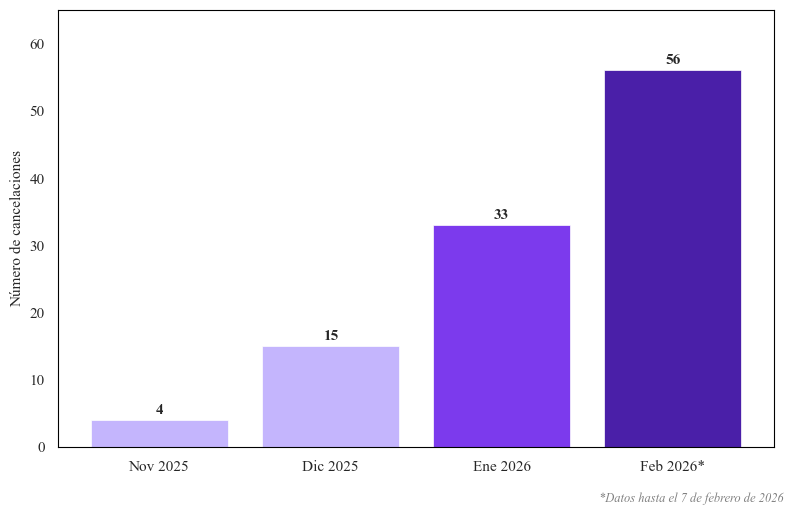

✅ Guardado: G_cancelaciones_temporales.png


In [44]:
sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize=(8, 5))

meses = ['Nov 2025', 'Dic 2025', 'Ene 2026', 'Feb 2026*']
valores = [4, 15, 33, 56]
colores = [PURPLE_LIGHT, PURPLE_LIGHT, PURPLE, '#4a1fa8']

bars = ax.bar(meses, valores, color=colores, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold',
            fontfamily='Times New Roman')

ax.set_ylabel('Número de cancelaciones', fontsize=11)
ax.set_ylim(0, 65)
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))

# Quitar gridlines
ax.grid(False)

# Recuadro completo (los cuatro lados)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color('black')

fig.text(0.99, -0.02, '*Datos hasta el 7 de febrero de 2026',
         ha='right', fontsize=9, color='gray', style='italic',
         fontfamily='Times New Roman')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'G_cancelaciones_temporales.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Guardado: G_cancelaciones_temporales.png')

---
## 8. Visualizaciones para el documento

Gráficos listos para incluir en el TFG.

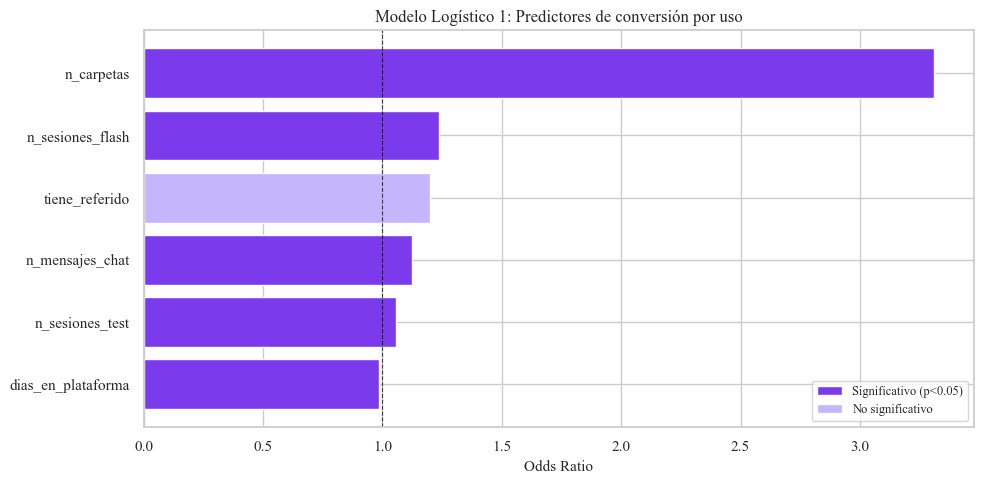

✅ Guardado: G_modelo1_odds_ratios.png


In [45]:
# Gráfico: Odds Ratios Modelo 1 (conversión)
fig, ax = plt.subplots(figsize=(10, 5))

or1_plot = odds_ratios1.sort_values('Odds Ratio')
colores = [PURPLE if p < 0.05 else PURPLE_LIGHT for p in or1_plot['p_valor']]

bars = ax.barh(or1_plot['Variable'], or1_plot['Odds Ratio'], color=colores)
ax.axvline(x=1, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_xlabel('Odds Ratio', fontsize=11)
ax.set_title('Modelo Logístico 1: Predictores de conversión por uso', fontsize=12)

# Leyenda manual
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor=PURPLE, label='Significativo (p<0.05)'),
    Patch(facecolor=PURPLE_LIGHT, label='No significativo')
]
ax.legend(handles=leyenda, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'G_modelo1_odds_ratios.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Guardado: G_modelo1_odds_ratios.png')

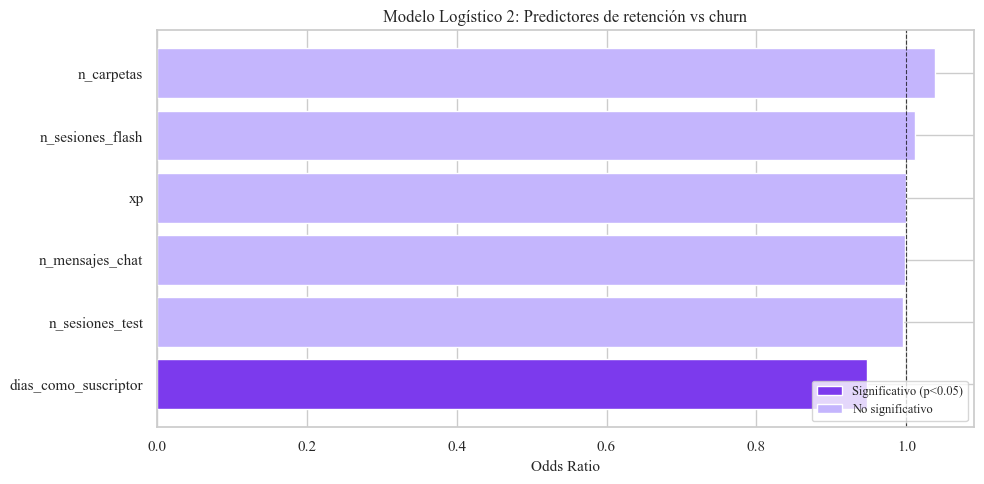

✅ Guardado: G_modelo2_odds_ratios.png


In [46]:
# Gráfico: Odds Ratios Modelo 2 (retención)
fig, ax = plt.subplots(figsize=(10, 5))

or2_plot = odds_ratios2.sort_values('Odds Ratio')
colores2 = [PURPLE if p < 0.05 else PURPLE_LIGHT for p in or2_plot['p_valor']]

ax.barh(or2_plot['Variable'], or2_plot['Odds Ratio'], color=colores2)
ax.axvline(x=1, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_xlabel('Odds Ratio', fontsize=11)
ax.set_title('Modelo Logístico 2: Predictores de retención vs churn', fontsize=12)
ax.legend(handles=leyenda, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'G_modelo2_odds_ratios.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Guardado: G_modelo2_odds_ratios.png')

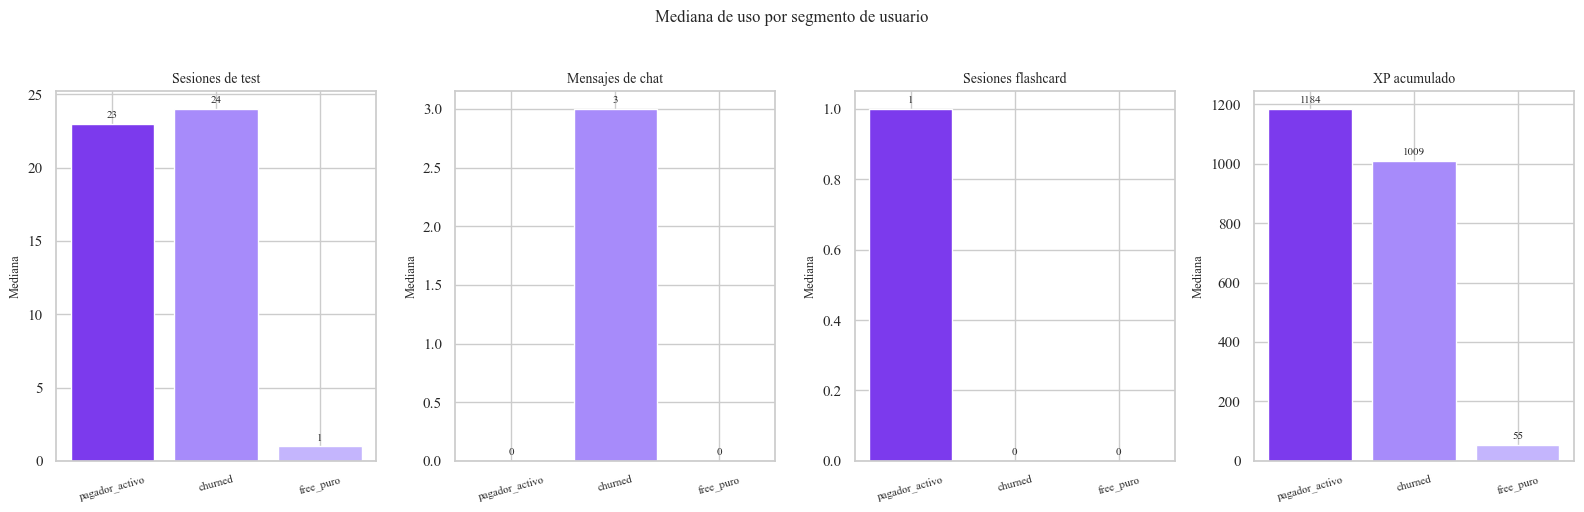

✅ Guardado: G_medianas_por_segmento.png


In [47]:
# Gráfico: Medianas por segmento para variables clave
vars_plot = ['n_sesiones_test', 'n_mensajes_chat', 'n_sesiones_flash', 'xp']
labels_plot = ['Sesiones de test', 'Mensajes de chat', 'Sesiones flashcard', 'XP acumulado']
segmentos_plot = ['pagador_activo', 'churned', 'free_puro']
colores_seg = [PURPLE, '#A78BFA', PURPLE_LIGHT]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, (var, label) in enumerate(zip(vars_plot, labels_plot)):
    medianas = [perfil[perfil['segmento'] == s][var].median() for s in segmentos_plot]
    bars = axes[i].bar(segmentos_plot, medianas, color=colores_seg)
    axes[i].set_title(label, fontsize=10)
    axes[i].set_ylabel('Mediana', fontsize=9)
    axes[i].tick_params(axis='x', rotation=15, labelsize=8)
    for bar, val in zip(bars, medianas):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(medianas)*0.01,
                     f'{val:.0f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Mediana de uso por segmento de usuario', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'G_medianas_por_segmento.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Guardado: G_medianas_por_segmento.png')

---
## 9. Resumen de outputs generados

Este notebook ha generado los siguientes archivos en `../outputs/`:

| Archivo | Contenido | Usado en |
|---------|-----------|----------|
| `perfil_usuarios.csv` | Dataset base con métricas de uso por usuario | Cap. 4 metodología |
| `tabla_descriptiva_segmentos.csv` | Estadísticos por segmento | Cap. 5.1 |
| `contrastes_mann_whitney.csv` | Resultados de los contrastes | Cap. 5.1 |
| `modelo1_odds_ratios.csv` | Resultados modelo conversión | Cap. 5.2 |
| `modelo2_odds_ratios.csv` | Resultados modelo retención | Cap. 5.3 |
| `G_medianas_por_segmento.png` | Gráfico comparativo | Cap. 5.1 |
| `G_modelo1_odds_ratios.png` | Gráfico odds ratios conversión | Cap. 5.2 |
| `G_modelo2_odds_ratios.png` | Gráfico odds ratios retención | Cap. 5.3 |

---
## 10. Análisis del valor diferencial MagIA vs SuperMagIA — Enero 2026

Cohorte: usuarios suscritos durante enero 2026 con plan mensual,
que no cancelaron en enero. Esta sección responde al objetivo
específico de evaluar si la coexistencia de dos niveles de IA
aporta valor diferencial en términos de uso, ingresos y sostenibilidad.

In [48]:
# ============================================================
# ANÁLISIS ECONÓMICO ENERO 2026 — Cohorte mensual
# ============================================================
# Cohorte: usuarios cuya subscription_created_at está en enero 2026,
#          con plan MENSUAL (no trimestral), que no cancelaron en enero.
# Comparativa: plan MagIA (6,99€) vs plan SuperMagIA (12,99€)
# Foco: dentro de SuperMagIA, descomponer coste IA por modelo usado.
# ============================================================

USD_TO_EUR = 0.8519  # Tipo medio USD/EUR enero 2026
INICIO_ENERO = pd.Timestamp('2026-01-01', tz='UTC')
FIN_ENERO    = pd.Timestamp('2026-01-31 23:59:59', tz='UTC')
INICIO_FEBRERO = pd.Timestamp('2026-02-01', tz='UTC')

# ------------------------------------------------------------
# 1. Construir la cohorte
# ------------------------------------------------------------
# Necesitamos cruzar users con subs para saber el price_amount
# (porque users.subscription_type no distingue mensual/trimestral)

# Suscripciones con su precio
subs_precio = subs[['customer', 'price_amount', 'price_interval',
                    'created', 'canceled_at', 'status']].copy()

# Una suscripción por usuario (la primera que tuvo)
# IMPORTANTE: si un usuario tiene más de una suscripción en Stripe,
# nos quedamos con la primera. Documentar esta decisión.
subs_precio = subs_precio.sort_values('created').drop_duplicates(
    subset='customer', keep='first'
)

# Cruzar con users
cohorte_base = users[
    users['subscription_created_at'].between(INICIO_ENERO, FIN_ENERO) &
    (users['subscription_type'].isin(['magia', 'supermagia']))
].merge(
    subs_precio,
    left_on='stripe_customer_id',
    right_on='customer',
    how='left'
)

print(f"Usuarios suscritos en enero (antes de filtrar): {len(cohorte_base):,}")
print(f"Distribución price_amount:")
print(cohorte_base['price_amount'].value_counts(dropna=False))

# Filtrar mensuales (699 = MagIA, 1299 = SuperMagIA)
cohorte = cohorte_base[
    cohorte_base['price_amount'].isin([699, 1299])
].copy()

# Excluir bajas de enero
cohorte['canceled_at'] = pd.to_datetime(cohorte['canceled_at'], utc=True, errors='coerce')
bajas_enero = cohorte['canceled_at'].between(INICIO_ENERO, FIN_ENERO)
print(f"\nBajas dadas durante enero (excluidas): {bajas_enero.sum()}")
cohorte = cohorte[~bajas_enero].copy()

print(f"\n✅ COHORTE FINAL: {len(cohorte):,} usuarios")
print(cohorte['subscription_type'].value_counts())

Usuarios suscritos en enero (antes de filtrar): 445
Distribución price_amount:
price_amount
699     338
1299     72
1699     26
3199      9
Name: count, dtype: int64

Bajas dadas durante enero (excluidas): 2

✅ COHORTE FINAL: 408 usuarios
subscription_type
magia         336
supermagia     72
Name: count, dtype: int64


In [49]:
# ------------------------------------------------------------
# 2. Ingresos en enero por usuario de la cohorte
# ------------------------------------------------------------
# Cobros exitosos de Stripe en enero, restringidos a la cohorte
charges_ok = charges[charges['status'] == 'succeeded'].copy()
charges_ok['created'] = parse_dates(charges_ok['created'])
charges_ok['amount_eur'] = charges_ok['amount'] / 100

# Filtrar cobros del periodo enero
charges_enero = charges_ok[
    charges_ok['created'].between(INICIO_ENERO, FIN_ENERO)
].copy()

# Solo cobros de la cohorte
ids_cohorte_stripe = set(cohorte['stripe_customer_id'].dropna())
charges_cohorte = charges_enero[
    charges_enero['customer'].isin(ids_cohorte_stripe)
].copy()

# Agregar ingresos por usuario
ingresos_usuario = (
    charges_cohorte.groupby('customer')
    .agg(
        ingresos_eur=('amount_eur', 'sum'),
        n_cobros=('id', 'count')
    )
    .reset_index()
    .rename(columns={'customer': 'stripe_customer_id'})
)

print(f"Cobros de la cohorte en enero: {len(charges_cohorte):,}")
print(f"Usuarios de la cohorte con al menos 1 cobro en enero: {len(ingresos_usuario):,}")
print(f"De {len(cohorte)} usuarios en cohorte → {len(cohorte) - len(ingresos_usuario)} sin cobro en enero")
print(f"\nIngresos totales en enero (cohorte): {charges_cohorte['amount_eur'].sum():,.2f} €")
print(f"\nDistribución de n_cobros por usuario:")
print(ingresos_usuario['n_cobros'].value_counts().sort_index())

# ------------------------------------------------------------
# 3. Coste IA en enero por usuario de la cohorte
# ------------------------------------------------------------
# Ya teníamos ai_spans con fechas parseadas, añadimos coste en EUR
ai_spans['cost_eur'] = ai_spans['cost'] * USD_TO_EUR

# Filtrar spans de enero
spans_enero = ai_spans[
    ai_spans['created_at'].between(INICIO_ENERO, FIN_ENERO)
].copy()

# Cruzar con traces para tener user_id
spans_enero_user = spans_enero.merge(
    traces[['id', 'user_id', 'related_object_type']],
    left_on='trace_id', right_on='id', how='left',
    suffixes=('', '_trace')
)

# Filtrar a usuarios de la cohorte
ids_cohorte = set(cohorte['id'])
spans_cohorte = spans_enero_user[
    spans_enero_user['user_id'].isin(ids_cohorte)
].copy()

# Agregar coste por usuario
costes_usuario = (
    spans_cohorte.groupby('user_id')
    .agg(
        coste_ia_eur=('cost_eur', 'sum'),
        n_spans=('cost_eur', 'count')
    )
    .reset_index()
    .rename(columns={'user_id': 'id'})
)

print(f"\nSpans IA de la cohorte en enero: {len(spans_cohorte):,}")
print(f"Usuarios con al menos 1 span: {len(costes_usuario):,}")
print(f"De {len(cohorte)} usuarios en cohorte → {len(cohorte) - len(costes_usuario)} sin actividad IA en enero")
print(f"\nCoste IA total en enero (cohorte): {spans_cohorte['cost_eur'].sum():,.2f} €")

Cobros de la cohorte en enero: 380
Usuarios de la cohorte con al menos 1 cobro en enero: 380
De 408 usuarios en cohorte → 28 sin cobro en enero

Ingresos totales en enero (cohorte): 2,768.20 €

Distribución de n_cobros por usuario:
n_cobros
1    380
Name: count, dtype: int64

Spans IA de la cohorte en enero: 26,592
Usuarios con al menos 1 span: 389
De 408 usuarios en cohorte → 19 sin actividad IA en enero

Coste IA total en enero (cohorte): 55.19 €


In [50]:
# ------------------------------------------------------------
# Investigar los 28 usuarios sin cobro en enero
# ------------------------------------------------------------
sin_cobro = cohorte[~cohorte['stripe_customer_id'].isin(ingresos_usuario['stripe_customer_id'])].copy()
print(f"Usuarios suscritos en enero sin cobro en enero: {len(sin_cobro)}")
print(f"\nDesglose por plan:")
print(sin_cobro['subscription_type'].value_counts())

# ¿Tienen cobro en otro mes? (por si se cobró antes/después)
otros_cobros = charges_ok[
    charges_ok['customer'].isin(sin_cobro['stripe_customer_id'])
]
print(f"\nDe esos 28, cuántos tienen ALGÚN cobro en Stripe (cualquier mes): "
      f"{otros_cobros['customer'].nunique()}")

# ¿Hay rastro de cupón asociado?
# (si tienes la variable tipo_cupon del cell 15)
if 'tipo_cupon' in cohorte.columns:
    print(f"\nDistribución tipo_cupon entre los 28 sin cobro:")
    print(sin_cobro['tipo_cupon'].value_counts(dropna=False))

Usuarios suscritos en enero sin cobro en enero: 28

Desglose por plan:
subscription_type
magia         16
supermagia    12
Name: count, dtype: int64

De esos 28, cuántos tienen ALGÚN cobro en Stripe (cualquier mes): 1


In [51]:
# ------------------------------------------------------------
# 4. Cohorte económica final (excluir 28 sin cobro en enero)
# ------------------------------------------------------------
cohorte_eco = cohorte.merge(
    ingresos_usuario,
    on='stripe_customer_id',
    how='inner'  # solo los que tienen cobro
)

# Añadir coste IA (los que no tienen spans → 0)
cohorte_eco = cohorte_eco.merge(
    costes_usuario, on='id', how='left'
)
cohorte_eco['coste_ia_eur'] = cohorte_eco['coste_ia_eur'].fillna(0)
cohorte_eco['n_spans']      = cohorte_eco['n_spans'].fillna(0)
cohorte_eco['margen_eur']   = cohorte_eco['ingresos_eur'] - cohorte_eco['coste_ia_eur']

print(f"✅ Cohorte económica final: {len(cohorte_eco):,} usuarios")
print(cohorte_eco['subscription_type'].value_counts())

# ------------------------------------------------------------
# 5. Resumen por plan
# ------------------------------------------------------------
resumen_plan = cohorte_eco.groupby('subscription_type').agg(
    n_usuarios=('id', 'count'),
    ingresos_total=('ingresos_eur', 'sum'),
    coste_ia_total=('coste_ia_eur', 'sum'),
    margen_total=('margen_eur', 'sum'),
    ingreso_medio=('ingresos_eur', 'mean'),
    coste_ia_medio=('coste_ia_eur', 'mean'),
    margen_medio=('margen_eur', 'mean'),
    coste_ia_mediano=('coste_ia_eur', 'median'),
    coste_ia_p90=('coste_ia_eur', lambda x: x.quantile(0.90)),
    coste_ia_p99=('coste_ia_eur', lambda x: x.quantile(0.99))
).round(3)

print("\n=== RESUMEN ECONÓMICO ENERO 2026 POR PLAN ===")
print(resumen_plan.T.to_string())

# ------------------------------------------------------------
# 6. Coste IA por modelo, dentro de cada plan
# ------------------------------------------------------------
# Cada span tiene model_mask (magia o supermagia)
# Cruzamos cohorte con spans_cohorte para ver qué modelos consume cada plan

spans_con_plan = spans_cohorte.merge(
    cohorte_eco[['id', 'subscription_type']],
    left_on='user_id', right_on='id', how='inner'
)

coste_por_modelo_por_plan = (
    spans_con_plan.groupby(['subscription_type', 'model_mask'])
    .agg(
        coste_eur=('cost_eur', 'sum'),
        n_spans=('cost_eur', 'count')
    )
    .round(3)
)

print("\n=== COSTE IA POR MODELO DENTRO DE CADA PLAN ===")
print(coste_por_modelo_por_plan.to_string())

# ------------------------------------------------------------
# 7. Foco en SuperMagIA: cuánto del coste viene del modelo premium
# ------------------------------------------------------------
super_users = cohorte_eco[cohorte_eco['subscription_type'] == 'supermagia']['id']
spans_super = spans_con_plan[spans_con_plan['user_id'].isin(super_users)]

# Coste por usuario SuperMagIA, descompuesto por modelo
coste_super_por_user = (
    spans_super.groupby(['user_id', 'model_mask'])['cost_eur']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)
coste_super_por_user.columns.name = None
# Asegurar que existen ambas columnas aunque algún plan no haya usado un modelo
for col in ['magia', 'supermagia']:
    if col not in coste_super_por_user.columns:
        coste_super_por_user[col] = 0

coste_super_por_user['coste_total'] = (
    coste_super_por_user['magia'] + coste_super_por_user['supermagia']
)
coste_super_por_user['pct_supermagia'] = (
    coste_super_por_user['supermagia'] / coste_super_por_user['coste_total'].replace(0, np.nan) * 100
).fillna(0).round(1)

print(f"\n=== USUARIOS SuperMagIA: ¿USAN EL MODELO PREMIUM? ===")
print(f"Total usuarios SuperMagIA en cohorte: {len(super_users)}")
print(f"Usuarios SuperMagIA con AL MENOS 1 span del modelo SuperMagIA: "
      f"{(coste_super_por_user['supermagia'] > 0).sum()}")
print(f"Usuarios SuperMagIA SIN ningún span del modelo SuperMagIA: "
      f"{(coste_super_por_user['supermagia'] == 0).sum()}")
print(f"\nDistribución del % de coste IA que es modelo SuperMagIA:")
print(coste_super_por_user['pct_supermagia'].describe().round(1))

✅ Cohorte económica final: 380 usuarios
subscription_type
magia         320
supermagia     60
Name: count, dtype: int64

=== RESUMEN ECONÓMICO ENERO 2026 POR PLAN ===
subscription_type     magia  supermagia
n_usuarios          320.000      60.000
ingresos_total     2079.300     688.900
coste_ia_total       43.071       9.775
margen_total       2036.229     679.125
ingreso_medio         6.498      11.482
coste_ia_medio        0.135       0.163
margen_medio          6.363      11.319
coste_ia_mediano      0.091       0.130
coste_ia_p90          0.307       0.310
coste_ia_p99          0.842       0.695

=== COSTE IA POR MODELO DENTRO DE CADA PLAN ===
                              coste_eur  n_spans
subscription_type model_mask                    
magia             magia           7.226     3085
                  supermagia      0.975      230
supermagia        magia           1.066      502
                  supermagia      0.873      279

=== USUARIOS SuperMagIA: ¿USAN EL MODELO PREMIUM?

In [52]:
# ¿Cuántos SuperMagIA NO tuvieron actividad de chat en enero?
chat_spans_super = spans_con_plan[
    (spans_con_plan['related_object_type'] == 'chat_conversation') &
    (spans_con_plan['subscription_type'] == 'supermagia')
]['user_id'].unique()

super_total = cohorte_eco[cohorte_eco['subscription_type'] == 'supermagia']['id']
super_sin_chat = set(super_total) - set(chat_spans_super)

print(f"SuperMagIA totales: {len(super_total)}")
print(f"SuperMagIA con AL MENOS 1 mensaje de chat en enero: {len(chat_spans_super)}")
print(f"SuperMagIA SIN ningún mensaje de chat en enero: {len(super_sin_chat)}")

# Y para tener el dato completo por modelo (filtrando solo chat)
spans_chat_super = spans_con_plan[
    (spans_con_plan['related_object_type'] == 'chat_conversation') &
    (spans_con_plan['user_id'].isin(super_total))
]
print(f"\nDe los SuperMagIA que SÍ usaron chat:")
print(f"  Solo MagIA model: {(spans_chat_super.groupby('user_id')['model_mask'].apply(lambda x: 'supermagia' not in x.values)).sum()}")
print(f"  Algún SuperMagIA model: {(spans_chat_super.groupby('user_id')['model_mask'].apply(lambda x: 'supermagia' in x.values)).sum()}")

SuperMagIA totales: 60
SuperMagIA con AL MENOS 1 mensaje de chat en enero: 28
SuperMagIA SIN ningún mensaje de chat en enero: 32

De los SuperMagIA que SÍ usaron chat:
  Solo MagIA model: 17
  Algún SuperMagIA model: 11


In [58]:
# Mismo análisis para usuarios del plan MagIA
magia_total = cohorte_eco[cohorte_eco['subscription_type'] == 'magia']['id']

chat_magia = spans_con_plan[
    (spans_con_plan['related_object_type'] == 'chat_conversation') &
    (spans_con_plan['user_id'].isin(magia_total))
]

chat_magia_users = chat_magia['user_id'].unique()
magia_sin_chat = set(magia_total) - set(chat_magia_users)

# De los que sí usaron chat, cuántos tocaron supermagia model
solo_magia = chat_magia.groupby('user_id')['model_mask'].apply(
    lambda x: 'supermagia' not in x.values
).sum()
algun_super = chat_magia.groupby('user_id')['model_mask'].apply(
    lambda x: 'supermagia' in x.values
).sum()

print(f"=== USUARIOS PLAN MAGIA (n={len(magia_total)}) ===")
print(f"  Sin chat alguno:               {len(magia_sin_chat)} ({len(magia_sin_chat)/len(magia_total)*100:.1f}%)")
print(f"  Con chat, solo modelo MagIA:   {solo_magia} ({solo_magia/len(magia_total)*100:.1f}%)")
print(f"  Con chat, algún SuperMagIA:    {algun_super} ({algun_super/len(magia_total)*100:.1f}%)")

# Métricas equivalentes para usuarios del plan SuperMagIA
super_total = cohorte_eco[cohorte_eco['subscription_type'] == 'supermagia']['id']

chat_super = spans_con_plan[
    (spans_con_plan['related_object_type'] == 'chat_conversation') &
    (spans_con_plan['user_id'].isin(super_total))
]

chat_super_users = chat_super['user_id'].unique()
super_sin_chat = set(super_total) - set(chat_super_users)

solo_magia_super = chat_super.groupby('user_id')['model_mask'].apply(
    lambda x: 'supermagia' not in x.values
).sum()

algun_super_super = chat_super.groupby('user_id')['model_mask'].apply(
    lambda x: 'supermagia' in x.values
).sum()

print(f"\n=== COMPARATIVA RESUMEN ===")
print(f"{'':30}{'MagIA':>10}{'SuperMagIA':>14}")
print(f"{'Total cohorte':30}{len(magia_total):>10}{len(super_total):>14}")
print(f"{'% sin chat alguno':30}{len(magia_sin_chat)/len(magia_total)*100:>10.1f}{len(super_sin_chat)/len(super_total)*100:>14.1f}")
print(f"{'% chat solo modelo MagIA':30}{solo_magia/len(magia_total)*100:>10.1f}{solo_magia_super/len(super_total)*100:>14.1f}")
print(f"{'% chat con modelo SuperMagIA':30}{algun_super/len(magia_total)*100:>10.1f}{algun_super_super/len(super_total)*100:>14.1f}")

=== USUARIOS PLAN MAGIA (n=320) ===
  Sin chat alguno:               174 (54.4%)
  Con chat, solo modelo MagIA:   126 (39.4%)
  Con chat, algún SuperMagIA:    20 (6.2%)

=== COMPARATIVA RESUMEN ===
                                   MagIA    SuperMagIA
Total cohorte                        320            60
% sin chat alguno                   54.4          53.3
% chat solo modelo MagIA            39.4          28.3
% chat con modelo SuperMagIA         6.2          18.3


In [54]:
# ------------------------------------------------------------
# Bloque A — Uso de modelos por usuario activo en chat
# ------------------------------------------------------------

# 1. Filtrar spans de chat de la cohorte
chat_spans_cohorte = spans_con_plan[
    spans_con_plan['related_object_type'] == 'chat_conversation'
].copy()

print(f"Spans de chat en la cohorte (enero): {len(chat_spans_cohorte):,}")
print(f"Usuarios únicos con chat: {chat_spans_cohorte['user_id'].nunique():,}")
print(f"\nDistribución por plan y modelo:")
print(chat_spans_cohorte.groupby(['subscription_type', 'model_mask']).size())

# 2. Métricas por usuario (un usuario, una fila)
chat_user_metrics = (
    chat_spans_cohorte
    .groupby(['user_id', 'subscription_type', 'model_mask'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Asegurarnos de que existen las dos columnas (por si no hay spans de un modelo)
for col in ['magia', 'supermagia']:
    if col not in chat_user_metrics.columns:
        chat_user_metrics[col] = 0

chat_user_metrics = chat_user_metrics.rename(
    columns={'magia': 'msgs_modelo_magia', 'supermagia': 'msgs_modelo_supermagia'}
)
chat_user_metrics['msgs_total'] = (
    chat_user_metrics['msgs_modelo_magia'] + chat_user_metrics['msgs_modelo_supermagia']
)
chat_user_metrics['pct_premium'] = (
    chat_user_metrics['msgs_modelo_supermagia']
    / chat_user_metrics['msgs_total'].replace(0, np.nan) * 100
).fillna(0)

# 3. Resumen por plan
resumen_uso_modelo = chat_user_metrics.groupby('subscription_type').agg(
    n_usuarios_activos=('user_id', 'count'),
    msgs_magia_medio=('msgs_modelo_magia', 'mean'),
    msgs_super_medio=('msgs_modelo_supermagia', 'mean'),
    msgs_total_medio=('msgs_total', 'mean'),
    msgs_total_mediano=('msgs_total', 'median'),
    pct_premium_medio=('pct_premium', 'mean'),
    pct_premium_mediano=('pct_premium', 'median'),
    pct_premium_p75=('pct_premium', lambda x: x.quantile(0.75))
).round(2)

print(f"\n=== USO DE MODELOS POR USUARIO ACTIVO EN CHAT (cohorte enero) ===")
print(resumen_uso_modelo.T.to_string())

# 4. Cuántos llegaron a usar el modelo premium al menos una vez
print(f"\n=== ¿USAN EL MODELO PREMIUM AL MENOS UNA VEZ? ===")
for plan in ['magia', 'supermagia']:
    df_plan = chat_user_metrics[chat_user_metrics['subscription_type'] == plan]
    n_total = len(df_plan)
    n_usaron_premium = (df_plan['msgs_modelo_supermagia'] > 0).sum()
    print(f"Plan {plan}: {n_usaron_premium}/{n_total} ({n_usaron_premium/n_total*100:.1f}%) usaron modelo premium")

Spans de chat en la cohorte (enero): 6,010
Usuarios únicos con chat: 174

Distribución por plan y modelo:
subscription_type  model_mask
magia              magia         3138
                   supermagia     393
supermagia         magia          506
                   supermagia     294
dtype: int64

=== USO DE MODELOS POR USUARIO ACTIVO EN CHAT (cohorte enero) ===
subscription_type     magia  supermagia
n_usuarios_activos   146.00       28.00
msgs_magia_medio      21.49       18.07
msgs_super_medio       2.69       10.50
msgs_total_medio      24.18       28.57
msgs_total_mediano    10.00       13.50
pct_premium_medio      4.86       25.34
pct_premium_mediano    0.00        0.00
pct_premium_p75        0.00       65.71

=== ¿USAN EL MODELO PREMIUM AL MENOS UNA VEZ? ===
Plan magia: 20/146 (13.7%) usaron modelo premium
Plan supermagia: 11/28 (39.3%) usaron modelo premium


In [55]:
# ------------------------------------------------------------
# Bloque B — ¿Se usa cada modelo de forma cualitativamente distinta?
# ------------------------------------------------------------

caracteristicas_modelo = chat_spans_cohorte.groupby('model_mask').agg(
    n_spans=('cost_eur', 'count'),
    prompt_tokens_medio=('prompt_tokens', 'mean'),
    prompt_tokens_mediano=('prompt_tokens', 'median'),
    completion_tokens_medio=('completion_tokens', 'mean'),
    completion_tokens_mediano=('completion_tokens', 'median'),
    latency_media=('latency', 'mean'),
    latency_mediana=('latency', 'median'),
    coste_medio_eur=('cost_eur', 'mean')
).round(2)

print("=== CARACTERÍSTICAS DE USO DE CADA MODELO (cohorte enero, todo el chat) ===")
print(caracteristicas_modelo.T.to_string())

# Test estadístico: ¿son los prompts de SuperMagIA significativamente más largos?
from scipy.stats import mannwhitneyu

prompts_magia = chat_spans_cohorte[chat_spans_cohorte['model_mask'] == 'magia']['prompt_tokens'].dropna()
prompts_super = chat_spans_cohorte[chat_spans_cohorte['model_mask'] == 'supermagia']['prompt_tokens'].dropna()

u, p = mannwhitneyu(prompts_super, prompts_magia, alternative='greater')
print(f"\nH1: prompts a modelo SuperMagIA tienen MÁS tokens que a MagIA")
print(f"U = {u:,.0f}, p = {p:.4e}")

completions_magia = chat_spans_cohorte[chat_spans_cohorte['model_mask'] == 'magia']['completion_tokens'].dropna()
completions_super = chat_spans_cohorte[chat_spans_cohorte['model_mask'] == 'supermagia']['completion_tokens'].dropna()

u2, p2 = mannwhitneyu(completions_super, completions_magia, alternative='greater')
print(f"\nH1: respuestas de modelo SuperMagIA tienen MÁS tokens que de MagIA")
print(f"U = {u2:,.0f}, p = {p2:.4e}")

=== CARACTERÍSTICAS DE USO DE CADA MODELO (cohorte enero, todo el chat) ===
model_mask                    magia  supermagia
n_spans                     3587.00      509.00
prompt_tokens_medio        21488.23    24702.39
prompt_tokens_mediano      13376.00    15575.00
completion_tokens_medio     1411.64     1346.02
completion_tokens_mediano    981.00      771.00
latency_media              16041.49    19876.11
latency_mediana            11949.00    13874.00
coste_medio_eur                0.00        0.00

H1: prompts a modelo SuperMagIA tienen MÁS tokens que a MagIA
U = 980,910, p = 3.2216e-03

H1: respuestas de modelo SuperMagIA tienen MÁS tokens que de MagIA
U = 836,295, p = 9.9892e-01


In [56]:
# ============================================================
# Verificación: ¿los SuperMagIA usan MÁS las funciones de test
# y flashcards que los MagIA? (Cohorte enero 2026)
# ============================================================

# ------------------------------------------------------------
# 1. Preguntas test generadas por usuario en enero
# ------------------------------------------------------------
# Reutilizamos preguntas_con_fechas si está construido. Si no, lo construimos.
# (Lo construyó el notebook 03; aquí lo recreamos por seguridad)

# Cargamos questions y tests si no están cargados
try:
    questions
except NameError:
    questions = pd.read_csv(DATA_PATH + "questions.csv", low_memory=False)
    tests     = pd.read_csv(DATA_PATH + "tests.csv", low_memory=False)
    questions['created_at'] = parse_dates(questions['created_at'])
    tests['created_at']     = parse_dates(tests['created_at'])

# Filtrar preguntas generadas con IA en enero
questions_ai_enero = questions[
    (questions['ai_assisted'] == True) &
    (questions['created_at'].between(INICIO_ENERO, FIN_ENERO))
].copy()

# Cruzar con tests para obtener user_id
preguntas_enero = questions_ai_enero.merge(
    tests[['id', 'user_id']].rename(columns={'id': 'test_id'}),
    on='test_id', how='left'
)

# Agregar por usuario
preguntas_por_user_enero = (
    preguntas_enero.groupby('user_id')
    .agg(n_preguntas_enero=('id', 'count'))
    .reset_index()
    .rename(columns={'user_id': 'id'})
)

# ------------------------------------------------------------
# 2. Flashcards generadas por usuario en enero
# ------------------------------------------------------------
try:
    notes
    cards
except NameError:
    notes = pd.read_csv(DATA_PATH + "notes.csv", low_memory=False)
    cards = pd.read_csv(DATA_PATH + "cards.csv", low_memory=False)
    notes['created_at'] = parse_dates(notes['created_at'])
    cards['created_at'] = parse_dates(cards['created_at'])

# Notes con IA en enero
notes_ai_enero = notes[
    (notes['ai_assisted'] == True) &
    (notes['created_at'].between(INICIO_ENERO, FIN_ENERO))
].copy()

# Cards de esos notes (cada note genera 1+ cards)
cards_enero = cards.merge(
    notes_ai_enero[['id', 'user_id']].rename(columns={'id': 'note_id'}),
    on='note_id', how='inner'
)

flashcards_por_user_enero = (
    cards_enero.groupby('user_id')
    .agg(n_flashcards_enero=('id', 'count'))
    .reset_index()
    .rename(columns={'user_id': 'id'})
)

# ------------------------------------------------------------
# 3. Cruzar con la cohorte económica
# ------------------------------------------------------------
cohorte_consumo = cohorte_eco[['id', 'subscription_type']].merge(
    preguntas_por_user_enero, on='id', how='left'
).merge(
    flashcards_por_user_enero, on='id', how='left'
)

cohorte_consumo['n_preguntas_enero']  = cohorte_consumo['n_preguntas_enero'].fillna(0)
cohorte_consumo['n_flashcards_enero'] = cohorte_consumo['n_flashcards_enero'].fillna(0)

# ------------------------------------------------------------
# 4. Resumen comparativo
# ------------------------------------------------------------
resumen_consumo = cohorte_consumo.groupby('subscription_type').agg(
    n_usuarios=('id', 'count'),
    preguntas_media=('n_preguntas_enero', 'mean'),
    preguntas_mediana=('n_preguntas_enero', 'median'),
    preguntas_p75=('n_preguntas_enero', lambda x: x.quantile(0.75)),
    preguntas_p95=('n_preguntas_enero', lambda x: x.quantile(0.95)),
    preguntas_max=('n_preguntas_enero', 'max'),
    flashcards_media=('n_flashcards_enero', 'mean'),
    flashcards_mediana=('n_flashcards_enero', 'median'),
    flashcards_p75=('n_flashcards_enero', lambda x: x.quantile(0.75)),
    flashcards_p95=('n_flashcards_enero', lambda x: x.quantile(0.95)),
    flashcards_max=('n_flashcards_enero', 'max'),
).round(1)

print("=== CONSUMO DE PREGUNTAS Y FLASHCARDS POR PLAN (cohorte enero 2026) ===")
print(resumen_consumo.T.to_string())

# ------------------------------------------------------------
# 5. ¿Cuántos SuperMagIA superan el techo del plan MagIA?
# Si tuvieran plan MagIA, ¿les habría limitado?
# ------------------------------------------------------------
LIMITE_MAGIA_PREGUNTAS  = 1500
LIMITE_MAGIA_FLASHCARDS = 3000

print(f"\n=== ¿LOS SUPERMAGIA NECESITAN EL TECHO MÁS ALTO? ===")

for plan in ['magia', 'supermagia']:
    df = cohorte_consumo[cohorte_consumo['subscription_type'] == plan]
    n_total = len(df)
    n_supera_p_magia = (df['n_preguntas_enero'] > LIMITE_MAGIA_PREGUNTAS).sum()
    n_supera_f_magia = (df['n_flashcards_enero'] > LIMITE_MAGIA_FLASHCARDS).sum()
    print(f"\nPlan {plan} (n={n_total}):")
    print(f"  Superan límite preguntas plan MagIA (>{LIMITE_MAGIA_PREGUNTAS}): {n_supera_p_magia} ({n_supera_p_magia/n_total*100:.1f}%)")
    print(f"  Superan límite flashcards plan MagIA (>{LIMITE_MAGIA_FLASHCARDS}): {n_supera_f_magia} ({n_supera_f_magia/n_total*100:.1f}%)")

# ------------------------------------------------------------
# 6. Test estadístico: ¿es el consumo significativamente distinto?
# ------------------------------------------------------------
from scipy.stats import mannwhitneyu

g_magia = cohorte_consumo[cohorte_consumo['subscription_type'] == 'magia']
g_super = cohorte_consumo[cohorte_consumo['subscription_type'] == 'supermagia']

u1, p1 = mannwhitneyu(
    g_super['n_preguntas_enero'], g_magia['n_preguntas_enero'],
    alternative='greater'
)
u2, p2 = mannwhitneyu(
    g_super['n_flashcards_enero'], g_magia['n_flashcards_enero'],
    alternative='greater'
)

print(f"\n=== TEST ESTADÍSTICO ===")
print(f"H1: SuperMagIA consume MÁS preguntas que MagIA")
print(f"  U = {u1:,.0f}, p = {p1:.4e}")
print(f"H1: SuperMagIA consume MÁS flashcards que MagIA")
print(f"  U = {u2:,.0f}, p = {p2:.4e}")

=== CONSUMO DE PREGUNTAS Y FLASHCARDS POR PLAN (cohorte enero 2026) ===
subscription_type    magia  supermagia
n_usuarios           320.0        60.0
preguntas_media      391.4       526.8
preguntas_mediana    311.0       340.0
preguntas_p75        600.5       719.2
preguntas_p95       1121.8      1616.5
preguntas_max       1871.0      2799.0
flashcards_media     180.9       224.0
flashcards_mediana    53.5        69.0
flashcards_p75       209.8       178.2
flashcards_p95       731.2       909.2
flashcards_max      3337.0      2199.0

=== ¿LOS SUPERMAGIA NECESITAN EL TECHO MÁS ALTO? ===

Plan magia (n=320):
  Superan límite preguntas plan MagIA (>1500): 5 (1.6%)
  Superan límite flashcards plan MagIA (>3000): 1 (0.3%)

Plan supermagia (n=60):
  Superan límite preguntas plan MagIA (>1500): 4 (6.7%)
  Superan límite flashcards plan MagIA (>3000): 0 (0.0%)

=== TEST ESTADÍSTICO ===
H1: SuperMagIA consume MÁS preguntas que MagIA
  U = 10,318, p = 1.7881e-01
H1: SuperMagIA consume MÁS flash

In [59]:
# ============================================================
# Verificación final: ¿qué fracción de los SuperMagIA realmente
# extrae valor diferencial del plan?
# ============================================================
# Definimos "extrae valor diferencial" como cumplir AL MENOS UNA
# de estas tres condiciones:
#   A) Usa el modelo SuperMagIA al menos una vez en el chat.
#   B) Genera más preguntas que el techo del plan MagIA (>1500).
#   C) Genera más flashcards que el techo del plan MagIA (>3000).

super_users = cohorte_eco[cohorte_eco['subscription_type'] == 'supermagia']['id']

# A) Usuarios SuperMagIA que usaron el modelo premium en el chat
super_uso_modelo_premium = set(
    chat_user_metrics[
        (chat_user_metrics['subscription_type'] == 'supermagia') &
        (chat_user_metrics['msgs_modelo_supermagia'] > 0)
    ]['user_id']
)

# B) Usuarios SuperMagIA que superan techo de preguntas plan MagIA
super_supera_preguntas = set(
    cohorte_consumo[
        (cohorte_consumo['subscription_type'] == 'supermagia') &
        (cohorte_consumo['n_preguntas_enero'] > 1500)
    ]['id']
)

# C) Usuarios SuperMagIA que superan techo de flashcards plan MagIA
super_supera_flashcards = set(
    cohorte_consumo[
        (cohorte_consumo['subscription_type'] == 'supermagia') &
        (cohorte_consumo['n_flashcards_enero'] > 3000)
    ]['id']
)

# Resumen individual
n_super = len(super_users)

print(f"=== EVIDENCIA INDIVIDUAL DE VALOR DIFERENCIAL (n={n_super} SuperMagIA) ===")
print(f"A) Usan modelo SuperMagIA en chat:    {len(super_uso_modelo_premium):2d} ({len(super_uso_modelo_premium)/n_super*100:4.1f}%)")
print(f"B) Superan techo preguntas MagIA:     {len(super_supera_preguntas):2d} ({len(super_supera_preguntas)/n_super*100:4.1f}%)")
print(f"C) Superan techo flashcards MagIA:    {len(super_supera_flashcards):2d} ({len(super_supera_flashcards)/n_super*100:4.1f}%)")

# Solapamiento
solo_a = super_uso_modelo_premium - super_supera_preguntas - super_supera_flashcards
solo_b = super_supera_preguntas - super_uso_modelo_premium - super_supera_flashcards
solo_c = super_supera_flashcards - super_uso_modelo_premium - super_supera_preguntas
a_y_b  = (super_uso_modelo_premium & super_supera_preguntas) - super_supera_flashcards
a_y_c  = (super_uso_modelo_premium & super_supera_flashcards) - super_supera_preguntas
b_y_c  = (super_supera_preguntas & super_supera_flashcards) - super_uso_modelo_premium
todos  = super_uso_modelo_premium & super_supera_preguntas & super_supera_flashcards

print(f"\n=== SOLAPAMIENTO ===")
print(f"Solo A (modelo premium):              {len(solo_a)}")
print(f"Solo B (techo preguntas):             {len(solo_b)}")
print(f"Solo C (techo flashcards):            {len(solo_c)}")
print(f"A + B (modelo y preguntas):           {len(a_y_b)}")
print(f"A + C (modelo y flashcards):          {len(a_y_c)}")
print(f"B + C (preguntas y flashcards):       {len(b_y_c)}")
print(f"Las tres a la vez:                    {len(todos)}")

# Unión: usuarios con ALGÚN tipo de valor diferencial
union = super_uso_modelo_premium | super_supera_preguntas | super_supera_flashcards
sin_valor = set(super_users) - union

print(f"\n=== RESULTADO FINAL ===")
print(f"SuperMagIA con AL MENOS UNA evidencia de valor diferencial: {len(union)} ({len(union)/n_super*100:.1f}%)")
print(f"SuperMagIA SIN ninguna evidencia (mismo perfil que MagIA):  {len(sin_valor)} ({len(sin_valor)/n_super*100:.1f}%)")

=== EVIDENCIA INDIVIDUAL DE VALOR DIFERENCIAL (n=60 SuperMagIA) ===
A) Usan modelo SuperMagIA en chat:    11 (18.3%)
B) Superan techo preguntas MagIA:      4 ( 6.7%)
C) Superan techo flashcards MagIA:     0 ( 0.0%)

=== SOLAPAMIENTO ===
Solo A (modelo premium):              10
Solo B (techo preguntas):             3
Solo C (techo flashcards):            0
A + B (modelo y preguntas):           1
A + C (modelo y flashcards):          0
B + C (preguntas y flashcards):       0
Las tres a la vez:                    0

=== RESULTADO FINAL ===
SuperMagIA con AL MENOS UNA evidencia de valor diferencial: 14 (23.3%)
SuperMagIA SIN ninguna evidencia (mismo perfil que MagIA):  46 (76.7%)
